In [120]:
# Import necessary libraries
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.inspection import PartialDependenceDisplay
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix,classification_report,roc_auc_score,log_loss,precision_recall_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder,label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,StratifiedKFold,train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
import requests
import io
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="dark")
pd.set_option('display.max_columns', 0)
pd.options.display.float_format = '{:.5f}'.format
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform, loguniform
import time
SEED = 42

In [121]:
df = pd.read_csv('./ncr_ride_bookings.csv')
print(df.shape)
df.head(5)

(150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.90000,14.00000,NaN,NaN,NaN,NaN,1.00000,Vehicle Breakdown,237.00000,5.73000,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.40000,25.80000,NaN,NaN,NaN,NaN,NaN,NaN,627.00000,13.58000,4.90000,4.90000,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.10000,28.50000,NaN,NaN,NaN,NaN,NaN,NaN,416.00000,34.02000,4.60000,5.00000,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.30000,19.60000,NaN,NaN,NaN,NaN,NaN,NaN,737.00000,48.21000,4.10000,4.30000,UPI


In [122]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [124]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.00000,102000.00000,10500.00000,27000.00000,9000.00000,102000.00000,102000.00000,93000.00000,93000.00000
mean,8.45635,29.14964,1.00000,1.00000,1.00000,508.29591,24.63701,4.23099,4.40458
std,3.77356,8.90258,0.00000,0.00000,0.00000,395.80577,14.00214,0.43687,0.43782
min,2.00000,10.00000,1.00000,1.00000,1.00000,50.00000,1.00000,3.00000,3.00000
25%,5.30000,21.60000,1.00000,1.00000,1.00000,234.00000,12.46000,4.10000,4.20000
50%,8.30000,28.80000,1.00000,1.00000,1.00000,414.00000,23.72000,4.30000,4.50000
75%,11.30000,36.80000,1.00000,1.00000,1.00000,689.00000,36.82000,4.60000,4.80000
max,20.00000,45.00000,1.00000,1.00000,1.00000,4277.00000,50.00000,5.00000,5.00000


In [125]:
df['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [126]:
df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

- All the cancellation/incomplete related columns are sparsely populated as they are relevant for non-complete rides like (cancelled by customer/driver etc.)

In [127]:
# removing inverted commas for customer id and booking id
df[['Customer ID','Booking ID']] = df[['Customer ID','Booking ID']].apply(lambda x: x.str.replace('"',''))

In [128]:
df[df['Booking ID'].duplicated(keep=False)].sort_values(by='Booking ID')

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
81334,2024-10-15,18:17:23,CNR1026036,Completed,CID6480133,Go Mini,Khandsa,Ashok Vihar,3.80000,43.30000,NaN,NaN,NaN,NaN,NaN,NaN,102.00000,36.51000,4.90000,4.20000,UPI
9192,2024-07-21,17:59:41,CNR1026036,No Driver Found,CID6974869,Go Mini,Seelampur,Nehru Place,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9587,2024-12-17,19:19:02,CNR1029172,Completed,CID6382731,Auto,Inderlok,Laxmi Nagar,6.90000,34.40000,NaN,NaN,NaN,NaN,NaN,NaN,332.00000,36.38000,4.30000,4.30000,UPI
1353,2024-01-19,17:00:57,CNR1029172,Incomplete,CID2615731,Bike,Jhilmil,Narsinghpur,4.70000,26.70000,NaN,NaN,NaN,NaN,1.00000,Customer Demand,429.00000,16.16000,NaN,NaN,UPI
82029,2024-11-05,16:50:20,CNR1051228,Completed,CID3177617,Auto,Dwarka Sector 21,Nehru Place,8.50000,24.80000,NaN,NaN,NaN,NaN,NaN,NaN,246.00000,4.80000,4.60000,4.50000,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95375,2024-12-10,10:11:30,CNR9962874,Cancelled by Driver,CID9468011,Auto,Narsinghpur,Ardee City,11.00000,NaN,NaN,NaN,1.00000,Customer related issue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57616,2024-02-01,23:46:39,CNR9971436,No Driver Found,CID8828441,Uber XL,Jhilmil,Ambience Mall,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86918,2024-09-11,12:33:46,CNR9971436,Incomplete,CID6082697,Go Mini,Hauz Rani,Connaught Place,9.50000,18.80000,NaN,NaN,NaN,NaN,1.00000,Other Issue,287.00000,11.68000,NaN,NaN,UPI
17651,2024-03-12,18:20:40,CNR9987527,Completed,CID9362124,Auto,Seelampur,Tagore Garden,2.10000,17.50000,NaN,NaN,NaN,NaN,NaN,NaN,832.00000,19.16000,4.10000,4.90000,UPI


There are some duplicate booking ids in the dataset, but these duplicate booking are having different customer, datetime etc. We cannot use Booking ID along as a primary key for calculating derived features.

- Sorting the data by customer id and data time to avoid data leakage while calculating historical features and split the data.

In [129]:
df['DateTime'] = pd.to_datetime(df['Date']+ " " +df['Time'])
df.drop(columns=['Date','Time'],inplace=True)

Extract Temporal Features

In [130]:
def extract_temporal_features(df,col):
    df[col] = pd.to_datetime(df[col])
    df['day_of_week'] = df[col].dt.dayofweek
    df['day_of_month'] = df[col].dt.day
    df['month'] = df[col].dt.month
    df['hour'] = df[col].dt.hour
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x>=5 else 0)
    return df

df = extract_temporal_features(df,'DateTime')

Geographical Feature Engineering

In [131]:
# sorting the dataset based on DateTime column to avoid data leakage while calculating density score
time_sorted_df = df[['Booking ID', 'Customer ID' ,'DateTime', 'Pickup Location','Drop Location', 'Booking Status']].sort_values(by='DateTime').copy()

time_sorted_df['is_completed'] = (time_sorted_df['Booking Status']=='Completed').astype(int)
time_sorted_df['is_not_completed'] = (time_sorted_df['Booking Status']!='Completed').astype(int)

# This ensures that for any ride, we only count rides that happened BEFORE it in absolute time.
time_sorted_df['ploc_cum_count'] = time_sorted_df.groupby('Pickup Location').cumcount()
time_sorted_df['dloc_cum_count'] = time_sorted_df.groupby('Drop Location').cumcount()
time_sorted_df['global_cum_count'] = np.arange(len(time_sorted_df))
time_sorted_df['ploc_cum_not_completed_rides'] = time_sorted_df.groupby('Pickup Location')['is_not_completed'].cumsum() - time_sorted_df['is_not_completed']
time_sorted_df['dloc_cum_non_completed_rides'] = time_sorted_df.groupby('Drop Location')['is_not_completed'].cumsum() - time_sorted_df['is_not_completed']

# adding 1 to denominator to avoid division by zero
# density score = count of rides at L observed prior to time t / total rides observed prior to time t
time_sorted_df['pickup_density_score'] = time_sorted_df['ploc_cum_count'] / (time_sorted_df['global_cum_count'] + 1)

time_sorted_df['pickup_non_completion_rate'] = (time_sorted_df['ploc_cum_not_completed_rides'])/ (time_sorted_df['ploc_cum_count']+1)

time_sorted_df['drop_non_completion_rate'] = (time_sorted_df['dloc_cum_non_completed_rides'])/ (time_sorted_df['dloc_cum_count'])

# since booking id is not unique we cannot use it alone as a primary key
merge_keys = ['Booking ID', 'Customer ID', 'DateTime']

features_to_merge = time_sorted_df[merge_keys + ['pickup_density_score','drop_non_completion_rate','pickup_non_completion_rate']]

df = df.merge(features_to_merge, how='left',on=merge_keys)

In [132]:
df[['pickup_density_score','pickup_non_completion_rate','drop_non_completion_rate']].describe()

,pickup_density_score,pickup_non_completion_rate,drop_non_completion_rate
count,150000.00000,150000.00000,149824.00000
mean,0.00568,0.37679,0.38029
std,0.00065,0.04404,0.04662
min,0.00000,0.00000,0.00000
25%,0.00547,0.36126,0.36236
50%,0.00567,0.37791,0.37931
75%,0.00587,0.39459,0.39700
max,0.08000,0.85714,1.00000


- There is good amount of variance in completion rates of pickup and drop location which means these features have some meaningful information

Customer Cancellation Rate, Completion Rate, Avg Spend

In [133]:
# Replacing NaN with zero
df['Cancelled Rides by Customer'].fillna(0,inplace=True)

# Sorting the dataset by Customer ID and DateTime to calculate past cancellation rate of customer for each row
customer_sorted_df = df[['Booking ID','Customer ID','DateTime','Cancelled Rides by Customer','Booking Status','Booking Value']].sort_values(by=['Customer ID','DateTime'])

cust_group = customer_sorted_df.groupby('Customer ID')

# customer cancellation rate
customer_sorted_df['customer_past_cancelled_count'] = cust_group['Cancelled Rides by Customer'].cumsum() - customer_sorted_df['Cancelled Rides by Customer']

customer_sorted_df['customer_total_rides'] = cust_group.cumcount()

customer_sorted_df['customer_cancellation_rate'] = (customer_sorted_df['customer_past_cancelled_count']/customer_sorted_df['customer_total_rides']).fillna(0)

# customer completion rate
customer_sorted_df['is_completed'] = (customer_sorted_df['Booking Status'] == 'Completed').astype(int)

customer_sorted_df['customer_past_completed'] = cust_group['is_completed'].cumsum() - customer_sorted_df['is_completed']

customer_sorted_df['customer_completion_rate'] = (customer_sorted_df['customer_past_completed']/customer_sorted_df['customer_total_rides']).fillna(0)

# customer spending power
customer_sorted_df['customer_past_spend_sum'] = cust_group['Booking Value'].cumsum() - customer_sorted_df['Booking Value']

customer_sorted_df['customer_avg_spend'] = (customer_sorted_df['customer_past_spend_sum'] / customer_sorted_df['customer_total_rides']).fillna(0)

merge_keys = ['Booking ID', 'Customer ID', 'DateTime']

features_to_merge = customer_sorted_df[merge_keys + ['customer_cancellation_rate','customer_completion_rate','customer_avg_spend']]

df = df.merge(features_to_merge,on=merge_keys,how='left')

del customer_sorted_df,time_sorted_df
gc.collect()

57788

Ride Distance Feature Engineering

In [134]:
df['Ride Distance'].isna().sum()

np.int64(48000)

Handling Ride Distance NaN values

In [135]:
df[df['Ride Distance'].isna()]['Booking Status'].unique()

array(['No Driver Found', 'Cancelled by Driver', 'Cancelled by Customer'],
      dtype=object)

- Ride distance is only available after rides completion so adding a flag for non available will have a leakage and model predict non completion if ride distance is not available

In [136]:
# replacing ride distance with pickup and drop location pair mean
df['Ride Distance'] = df.groupby(['Pickup Location','Drop Location'])['Ride Distance'].transform('median')

In [137]:
df['Ride Distance'].isna().sum()

np.int64(1790)

There are 1790 NaN values still(very low), these are new pickup and drop locations pairs. So replacing these with pickup location avg ride distance instead of creating seperate missing indicator column

In [138]:
df['Ride Distance'] = df['Ride Distance'].fillna(df.groupby('Pickup Location')['Ride Distance'].transform('median'))
df['Ride Distance'].isna().sum()

np.int64(0)

In [139]:
df['Booking Value'].isna().sum()

np.int64(48000)

Handling NaN value in Booking Value column

In [140]:
df[df['Booking Value'].isna()]['Booking Status'].unique()

array(['No Driver Found', 'Cancelled by Driver', 'Cancelled by Customer'],
      dtype=object)

- Booking Value is only available after rides completion so adding a flag for non available will have a leakage and model predict non completion if Booking value is not available

In [141]:
# replacing nan value in Booking value with estimated booking value based on vehicle category and ride distance
valid_rows = df[~(df['Booking Value'].isna())]

# calculating price per km 
valid_rows['price_per_km'] = valid_rows['Booking Value']/valid_rows['Ride Distance']

# Median of price per km for each vehicle type
vehicle_wise_price_per_km = valid_rows.groupby('Vehicle Type')['price_per_km'].median()

# Overall price per km median to replace new vehicle type category
global_price_per_km = valid_rows['price_per_km'].median()

def fill_booking_value(row):
    if pd.isnull(row['Booking Value']):
        return vehicle_wise_price_per_km.get(row['Vehicle Type'], global_price_per_km) * row['Ride Distance']
    else:
        return row['Booking Value']

df['Booking Value'] = df.apply(fill_booking_value,axis=1)

In [142]:
df['Booking Value'].isna().sum()

np.int64(0)

For handling Nan value in Booking Value column, I haven't created seperate missing indicator column and replace Nan with 0 or -1 because in real world or at time of prediction booking value will be shown to user of each vehicle category, so I have calculated booking value for nan rows based on vehicle type and distance (price will never be missing at time of prediction). And also if we use missing indicator the model will learn that is booking value is missed then booking status will be negative class which is not correct.

In [143]:
# Trip Duration Feature
# Defining speed map based on peak hours and traffic
speed_map = {
    0: 60, 1: 60, 2: 60, 3: 60, 4: 60, 5: 60,  # Late Night (Fast)
    6: 50, 7: 30, 8: 25, 9: 15, 10: 15, 11: 18, # Morning Peak (Slow)
    12: 22, 13: 22, 14: 22, 15: 20, 16: 20,     # Afternoon (Moderate)
    17: 15, 18: 12, 19: 15, 20: 18, 21: 20,     # Evening Peak (Worst)
    22: 30, 23: 50                              # Night (Clearing up)
}

df['est_speed_kmph'] = df['hour'].map(speed_map)
df['est_trip_duration_mins'] = np.round((df['Ride Distance']/df['est_speed_kmph'])*60).astype(int)

# Earnings per min
df['est_value_per_min'] = df['Booking Value'] / (df['est_trip_duration_mins'] + 1)

df.drop('est_speed_kmph',axis=1,inplace=True)

In [144]:
df[['est_trip_duration_mins','est_value_per_min']].describe()

,est_trip_duration_mins,est_value_per_min
count,150000.00000,150000.00000
mean,76.09919,8.66720
std,40.96743,10.68557
min,1.00000,0.23744
25%,44.00000,3.83929
50%,71.00000,5.85783
75%,102.00000,9.40541
max,250.00000,472.80000


Handling Avg CTAT and VTAT NaN values

In [145]:
df[['Avg CTAT','Avg VTAT']].isna().sum()

Avg CTAT    48000
Avg VTAT    10500
dtype: int64

In [146]:
df.loc[df['Avg CTAT'].isna(),'Booking Status'].unique()

array(['No Driver Found', 'Cancelled by Driver', 'Cancelled by Customer'],
      dtype=object)

In [147]:
df.loc[df['Avg VTAT'].isna(),'Booking Status'].unique()

array(['No Driver Found'], dtype=object)

- These values are only generated when a driver is actually found or considered.
- NaN for CTAT means the driver is not found, or ride is cancelled.
- NaN for VTAT means driver is not found.

In [148]:
df['Avg VTAT'] = df['Avg VTAT'].fillna(
    df.groupby('Vehicle Type')['Avg VTAT'].transform('median')
)

df['Avg CTAT'] = df['Avg CTAT'].fillna(
    df.groupby('Vehicle Type')['Avg CTAT'].transform('median')
)

- Replaced Nan values of CTAT and VTAT columns with their respective vehicle category median

In [149]:
df[['Avg CTAT','Avg VTAT']].isna().sum()

Avg CTAT    0
Avg VTAT    0
dtype: int64

EDA

In [150]:
# defining the target variable
df['target'] = (df['Booking Status']=='Completed').astype(int)

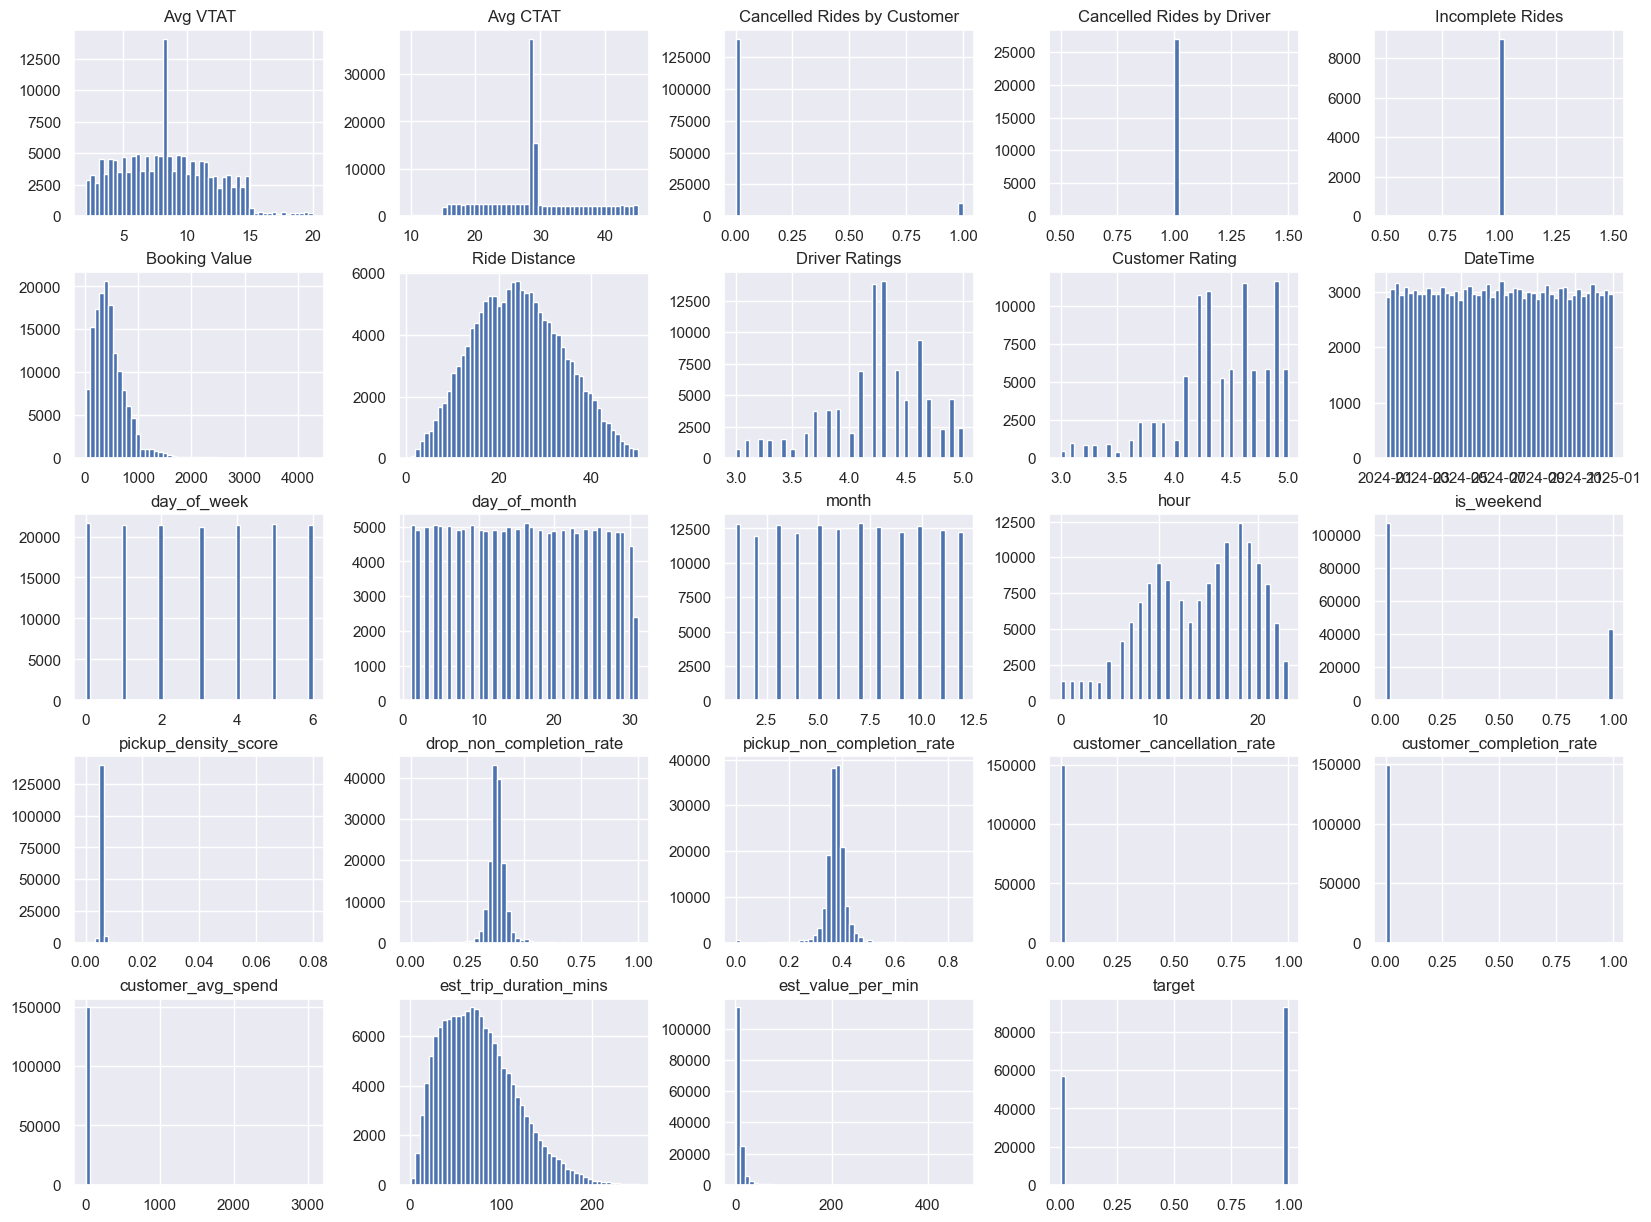

In [151]:
df.hist(figsize=(20,15), bins=50)  
plt.show()

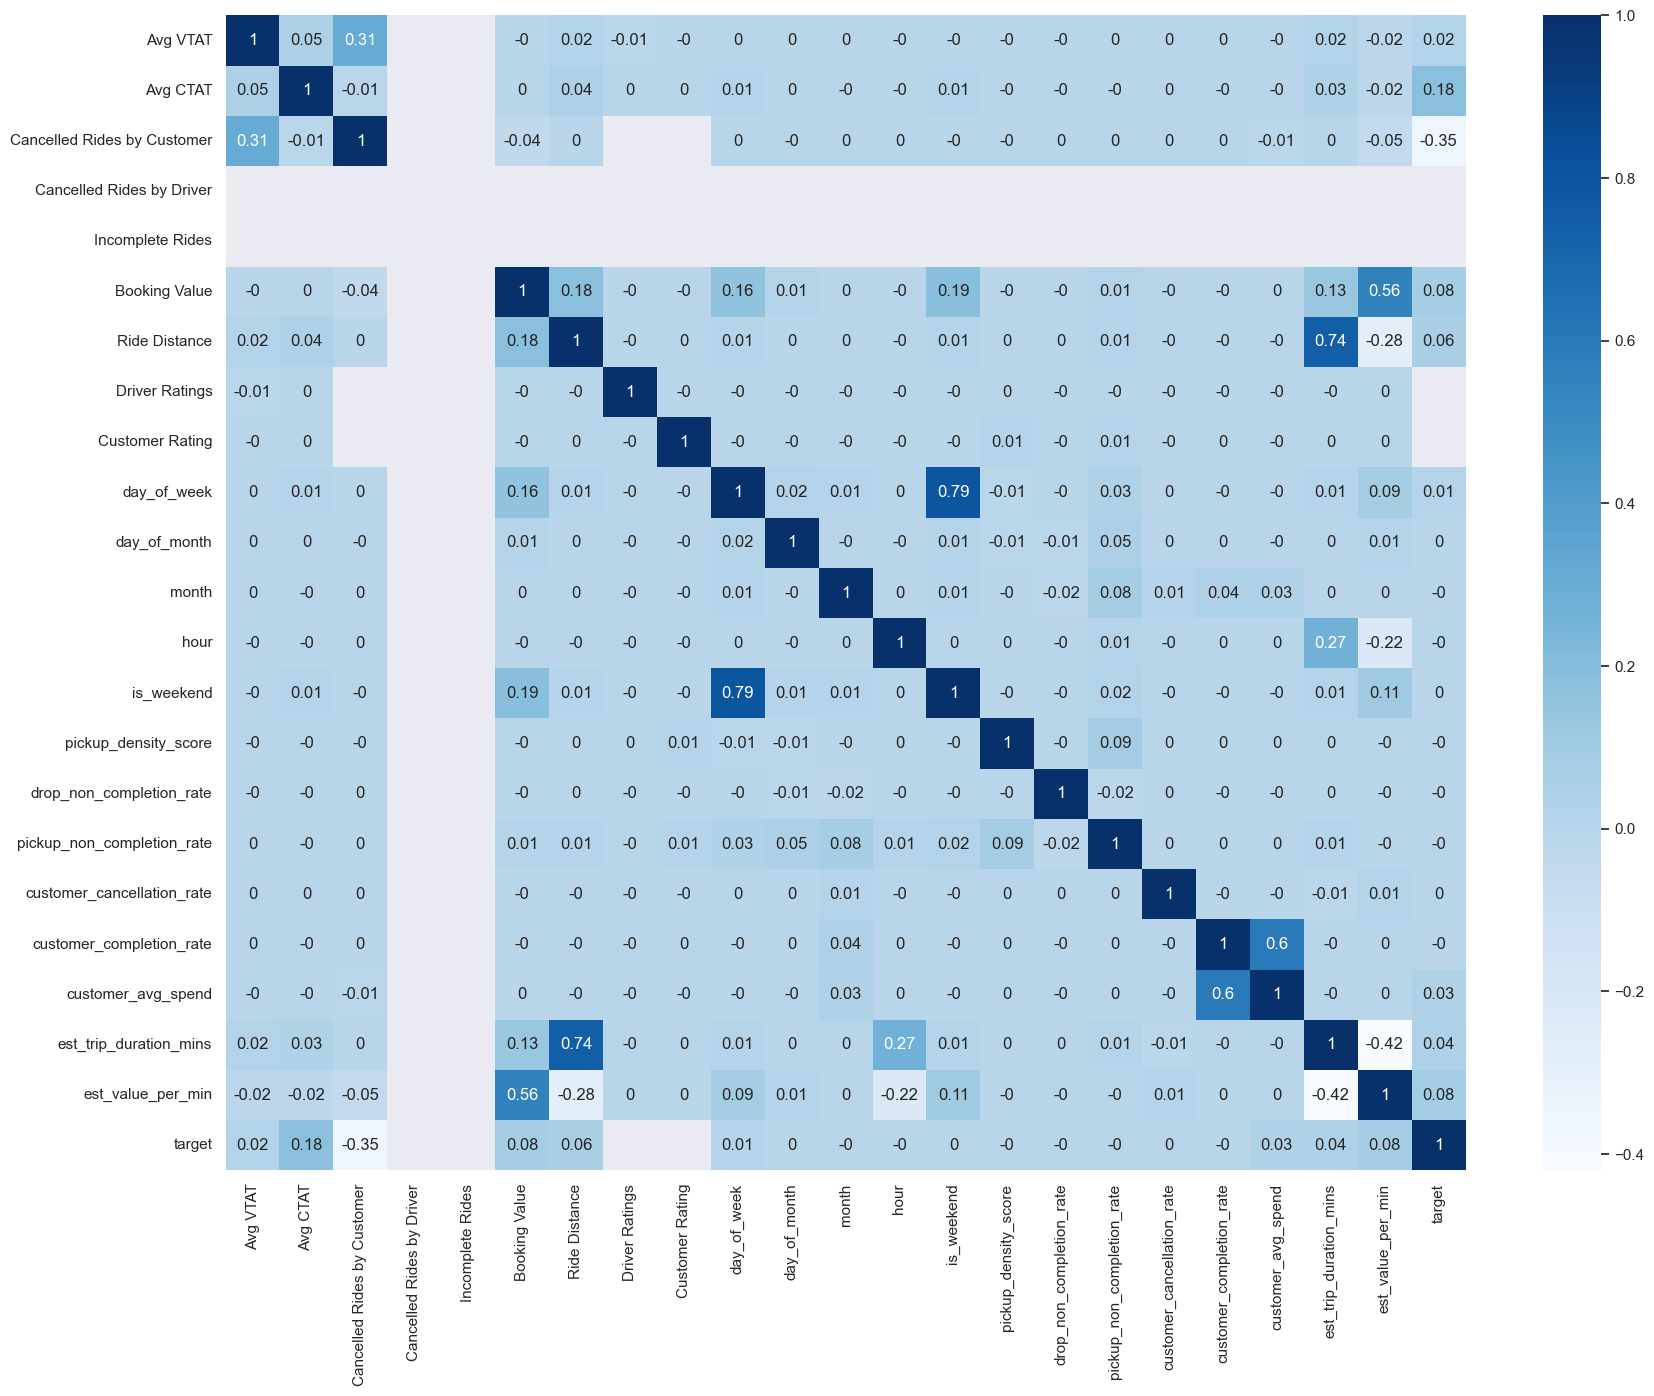

In [152]:
corr_mat = df.corr(numeric_only=True)
plt.figure(figsize=(20, 15))
corr_heatmap=sns.heatmap(np.round(df.corr(numeric_only=True),2), cmap="Blues", annot=True)

- As we can there are some columns other than target column which are having correlation

Peak Hour Analysis

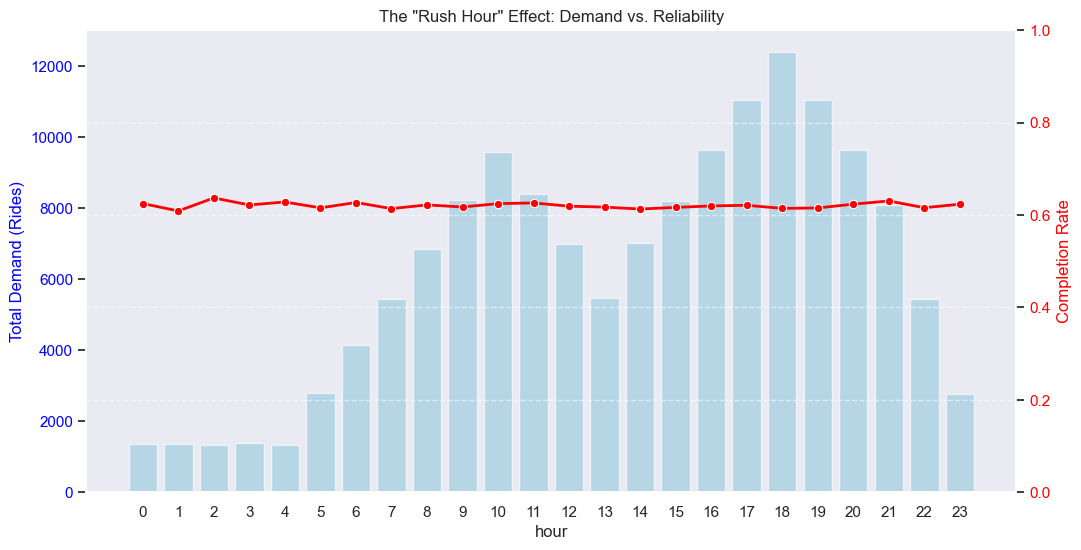

In [153]:
# 1. Aggregate data by Hour
hourly_stats = df.groupby('hour').agg(
    total_rides=('Booking ID', 'count'),
    completion_rate=('target', 'mean') # 'target' is 1 for Completed, 0 for others
).reset_index()

# 2. Plotting (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Volume (Demand)
sns.barplot(data=hourly_stats, x='hour', y='total_rides', color='skyblue', alpha=0.6, ax=ax1)
ax1.set_ylabel('Total Demand (Rides)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line chart for Completion Rate (Reliability)
ax2 = ax1.twinx()
sns.lineplot(data=hourly_stats, x='hour', y='completion_rate', color='red', marker='o', linewidth=2, ax=ax2)
ax2.set_ylabel('Completion Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1) # Fix range 0-100%

plt.title('The "Rush Hour" Effect: Demand vs. Reliability')
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

In [154]:
hourly_stats.sort_values(by='completion_rate')

,hour,total_rides,completion_rate
1,1,1360,0.60882
14,14,7031,0.61300
7,7,5450,0.61394
18,18,12397,0.61442
19,19,11047,0.61537
5,5,2786,0.61558
22,22,5441,0.61588
15,15,8202,0.61656
13,13,5470,0.61718
9,9,8234,0.61744


- As we can see there are some peak hours when demand is very high. Peak hours are between 8 to 11 and 16 to 20.
- And Completion rate appears stable (flat variance), which means even when the demand is high supply chain is scaling well, keeping the percentage of success constant. But there is a problem lets say at off peak hours there are 1000 rides and 10% failure which is 100 angry customers and in peak hours when there are 10000 rides and 10% failures which means 1000 angry customers.
- hours which are having least completion rate are 1,14,7,18.
- Due to this system is loosing revenue during peak hours, even if the completetion rate line look flat. Our model is crucial here to save those values during peak hours

Adding peak hour flag for high demand hours

In [155]:
peak_hours = [7,8,9,10,11,12,14,15,16,17,18,19,21]
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if x in peak_hours else 0)

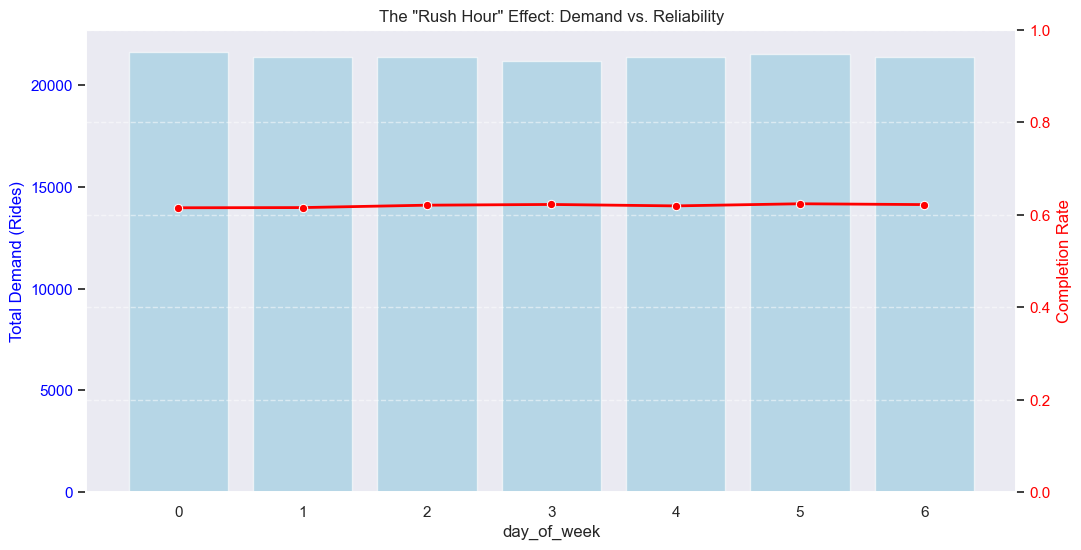

In [156]:
# 1. Aggregate data by Hour
days_stats = df.groupby('day_of_week').agg(
    total_rides=('Booking ID', 'count'),
    completion_rate=('target', 'mean') # 'target' is 1 for Completed, 0 for others
).reset_index()

# 2. Plotting (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Volume (Demand)
sns.barplot(data=days_stats, x='day_of_week', y='total_rides', color='skyblue', alpha=0.6, ax=ax1)
ax1.set_ylabel('Total Demand (Rides)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line chart for Completion Rate (Reliability)
ax2 = ax1.twinx()
sns.lineplot(data=days_stats, x='day_of_week', y='completion_rate', color='red', marker='o', linewidth=2, ax=ax2)
ax2.set_ylabel('Completion Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1) # Fix range 0-100%

plt.title('The "Rush Hour" Effect: Demand vs. Reliability')
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

There is not much variance in the completion rate and demand on days of week, It is not indicating any useful information.

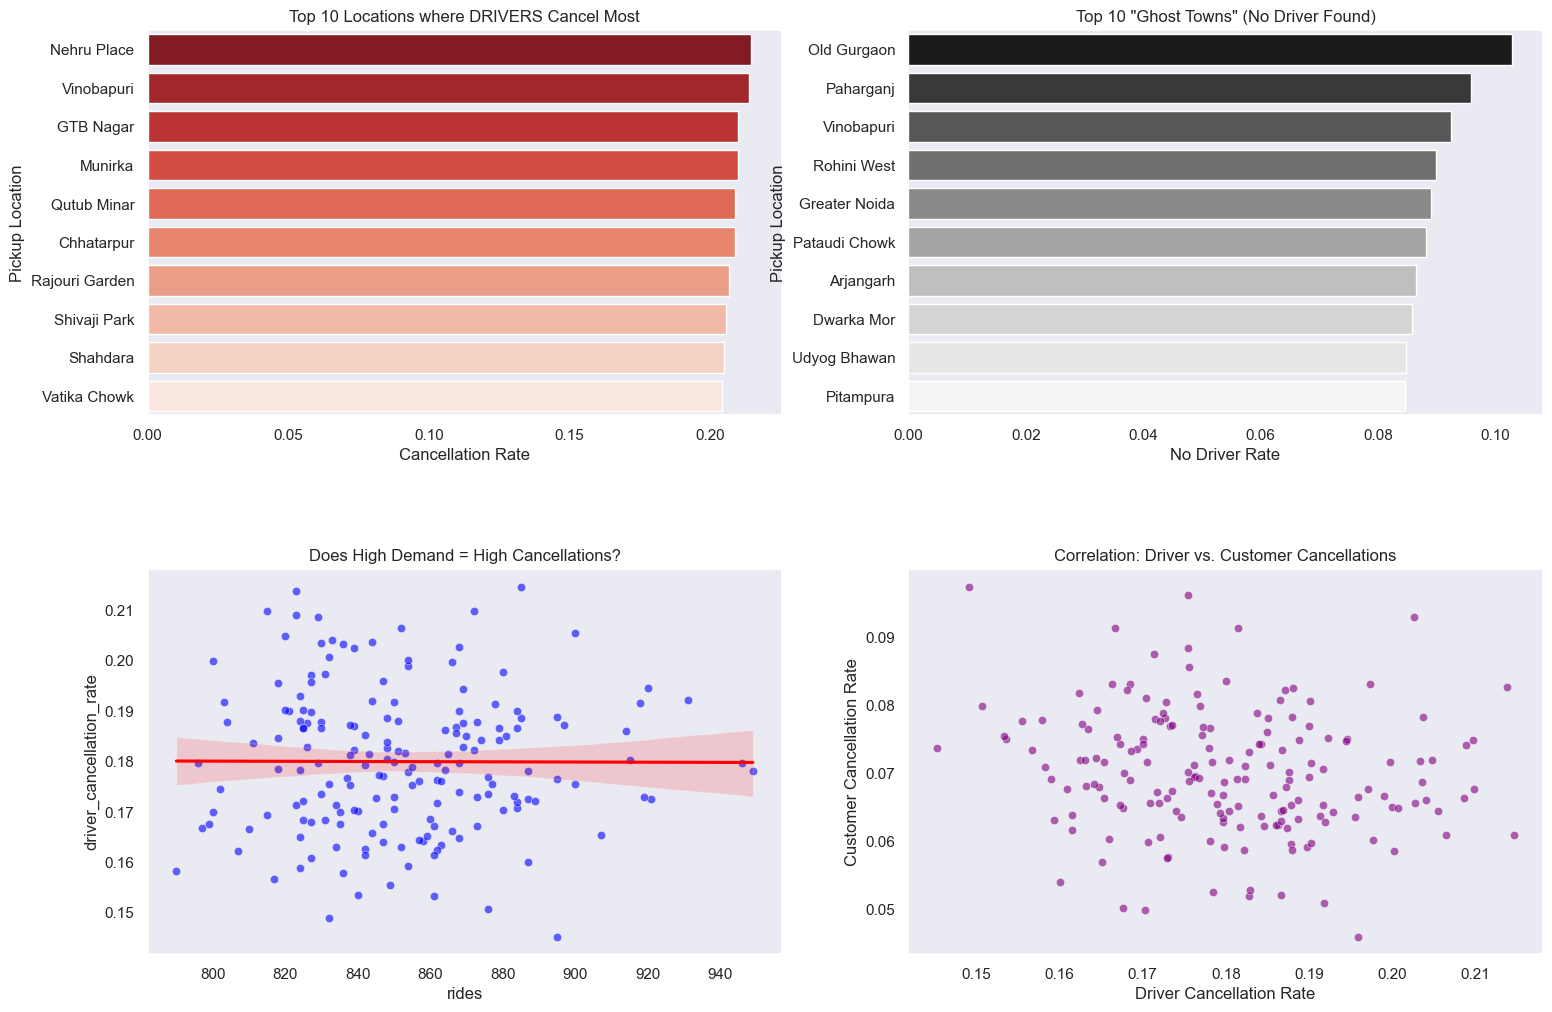

In [157]:
# filter for locations with significant volume (e.g., > 100 rides) to avoid noise
df['is_cancelled_by_driver'] = (df['Booking Status'] == 'Cancelled by Driver').astype(int)
df['is_cancelled_by_customer'] = (df['Booking Status'] == 'Cancelled by Customer').astype(int)
df['is_driver_not_found'] = (df['Booking Status'] == 'No Driver Found').astype(int)

loc_stats = df.groupby('Pickup Location').agg(
    rides=('Booking ID', 'count'),
    driver_cancellation_rate= ('is_cancelled_by_driver','mean'),
    customer_cancellation_rate= ('is_cancelled_by_customer','mean'),
    driver_not_found_rate= ('is_driver_not_found','mean')
)

plot_data = loc_stats.reset_index() 

# Set up a 2x2 Dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4)

# --- Plot 1: The "Driver Rejection" Zones (Top 10 Highest Driver Cancellation) ---
top_driver_cancel = plot_data.sort_values('driver_cancellation_rate', ascending=False).head(10)
sns.barplot(data=top_driver_cancel, x='driver_cancellation_rate', y='Pickup Location', ax=axes[0, 0], palette='Reds_r')
axes[0, 0].set_title('Top 10 Locations where DRIVERS Cancel Most')
axes[0, 0].set_xlabel('Cancellation Rate')

# --- Plot 2: The "Ghost Towns" (Top 10 Highest No Driver Found) ---
top_no_driver = plot_data.sort_values('driver_not_found_rate', ascending=False).head(10)
sns.barplot(data=top_no_driver, x='driver_not_found_rate', y='Pickup Location', ax=axes[0, 1], palette='Greys_r')
axes[0, 1].set_title('Top 10 "Ghost Towns" (No Driver Found)')
axes[0, 1].set_xlabel('No Driver Rate')

# --- Plot 3: Volume vs. Risk (Scatter) ---
# Question: Do busy locations have better service?
sns.scatterplot(data=plot_data, x='rides', y='driver_cancellation_rate', alpha=0.6, color='blue', ax=axes[1, 0])
axes[1, 0].set_title('Does High Demand = High Cancellations?')
axes[1, 0].set_xlabel('Total Rides (Volume)')
axes[1, 0].set_ylabel('Driver Cancellation Rate')
# Add a trendline to see the correlation
sns.regplot(data=plot_data, x='rides', y='driver_cancellation_rate', scatter=False, ax=axes[1, 0], color='red')

# --- Plot 4: Customer vs. Driver Frustration ---
# Question: If drivers cancel, do customers also cancel (out of anger)?
sns.scatterplot(data=plot_data, x='driver_cancellation_rate', y='customer_cancellation_rate', alpha=0.6, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Correlation: Driver vs. Customer Cancellations')
axes[1, 1].set_xlabel('Driver Cancellation Rate')
axes[1, 1].set_ylabel('Customer Cancellation Rate')

plt.show()

- Vinobapuri (21.3%) and Akshardham (20.2%) are absolute nightmares for customers due to high driver cancellation rate.
- Old Gurgaon, Paharganj pick up locaiton are having difficulty in finding the driver, which means supply is low at these locations.
- Driver Cancellations are not volume driven, volume alone is a weak predictor

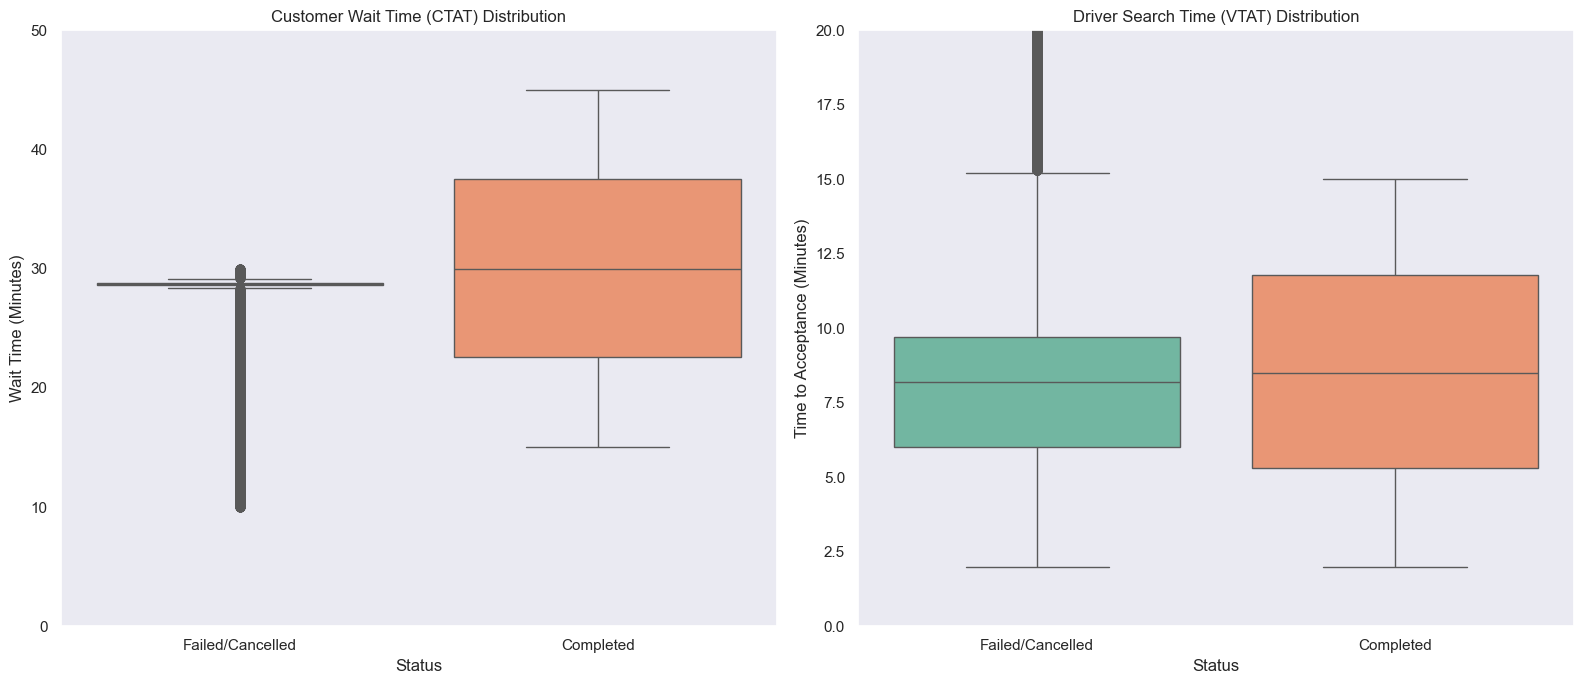

In [158]:
# 1. Filter: We only want to look at rides where a driver was actually found (Value > 0)
# -1 values (No Supply) would skew the chart, so we remove them for this specific view.
plot_data = df[(df['Avg CTAT'] > 0) & (df['Avg VTAT'] > 0)].copy()

# 2. Rename Target for better labels in the plot
plot_data['Status'] = plot_data['target'].map({1: 'Completed', 0: 'Failed/Cancelled'})

# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Customer Wait Time (CTAT) ---
sns.boxplot(data=plot_data, x='Status', y='Avg CTAT', palette='Set2', ax=axes[0])
axes[0].set_title('Customer Wait Time (CTAT) Distribution')
axes[0].set_ylabel('Wait Time (Minutes)')
axes[0].set_ylim(0, 50) # Focus on the core range

# --- Plot 2: Driver Search Time (VTAT) ---
sns.boxplot(data=plot_data, x='Status', y='Avg VTAT', palette='Set2', ax=axes[1])
axes[1].set_title('Driver Search Time (VTAT) Distribution')
axes[1].set_ylabel('Time to Acceptance (Minutes)')
axes[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()

CTAT Plot
- Longer CTAT rides that still complete represent patient customers
- Short CTAT failures are likely driver-side or matching failures

VTAT Plot
- Higher VTAT in Failed rides

In [159]:
df['is_cancelled'] = ((df['Booking Status']=='Cancelled by Driver') | (df['Booking Status']=='Cancelled by Customer') | (df['Booking Status']=='No Driver Found')).astype(int)

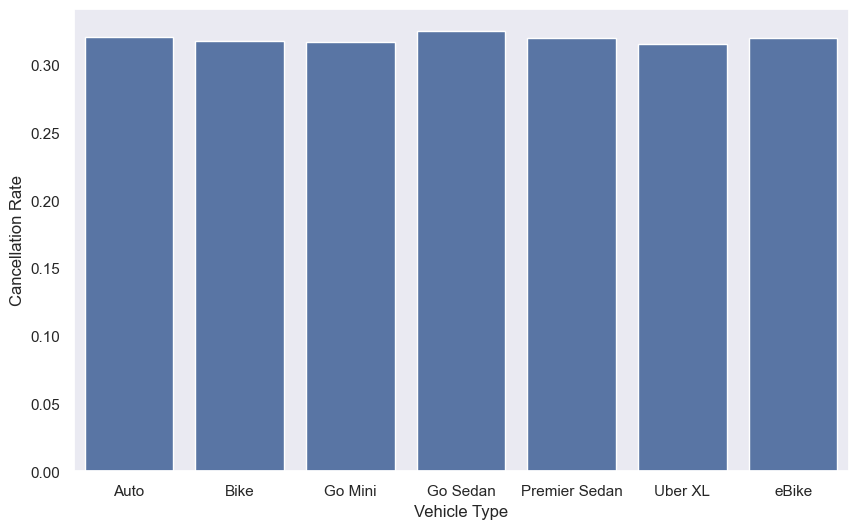

In [160]:
vehicle_wise_risk = df.groupby('Vehicle Type')['is_cancelled'].mean().reset_index(name='Cancellation Rate')
plt.figure(figsize=(10,6))
sns.barplot(data=vehicle_wise_risk,x='Vehicle Type',y='Cancellation Rate')
plt.show()

- There cancellation rate is uniform across different vechicle categories, but go sedan, Bike, premier sedan are having high cancellation rate when compared to other vehicle categories which indicates that these vehicle type require supply and price management

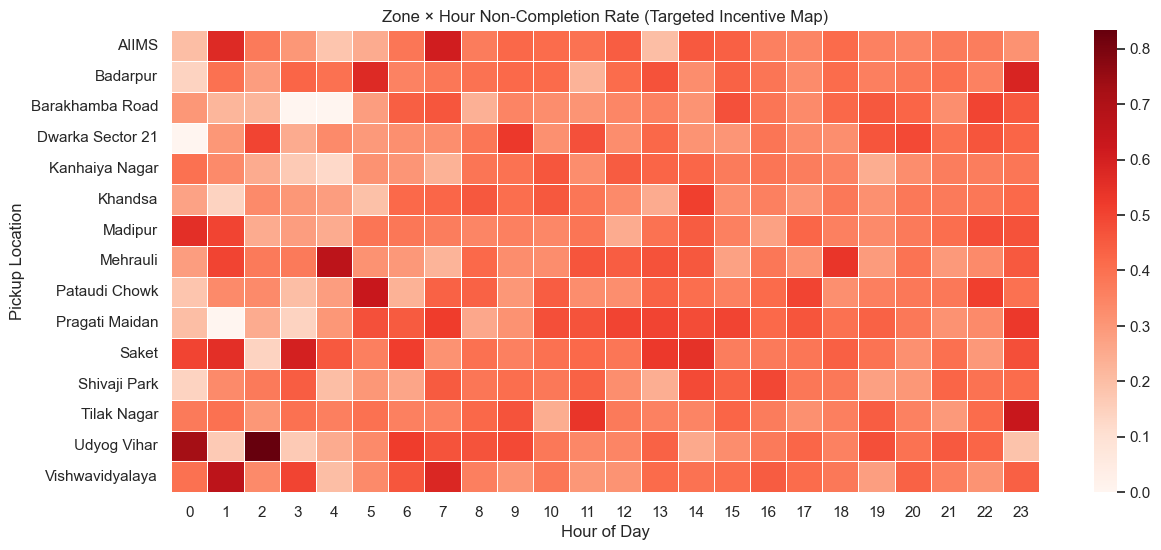

In [161]:
df['non_completion'] = 1 - df['target']
top_zones = (
    df['Pickup Location']
    .value_counts()
    .head(15)
    .index
)

zone_hour = (
    df[df['Pickup Location'].isin(top_zones)]
    .groupby(['Pickup Location', 'hour'])['non_completion']
    .mean()
    .reset_index()
)

pivot_zone_hour = zone_hour.pivot(
    index='Pickup Location',
    columns='hour',
    values='non_completion'
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_zone_hour,
    cmap='Reds',
    linewidths=0.5
)
plt.title("Zone × Hour Non-Completion Rate (Targeted Incentive Map)")
plt.xlabel("Hour of Day")
plt.ylabel("Pickup Location")
plt.show()


The zone-hour heatmap reveals localized reliability failures that are not explained by global demand patterns. For example, Saket and Madipur show a 15–25% higher non-completion rate during evening hours (6–9 PM), while Udyog Vihar exhibits consistently elevated risk across all hours. These segments represent high-ROI targets for geo-fenced driver incentives and dynamic pricing.

In [162]:
df.groupby('Customer ID')['customer_cancellation_rate'].mean().sort_values(ascending=False).reset_index(name='Cancellation Rate').head(10)

,Customer ID,Cancellation Rate
0,CID5537003,0.50000
1,CID7939117,0.50000
2,CID9191765,0.50000
3,CID5606206,0.50000
4,CID3442668,0.50000
5,CID5484173,0.50000
6,CID5858606,0.50000
7,CID2701120,0.50000
8,CID3716593,0.50000
9,CID3788493,0.50000


- There are the customers whose cancellation rate is higher, we need to do prioritise high rating drivers, and less Avg CTAT by increasing supply for these customer zones.

Target Class distribution

In [163]:
df['target'].value_counts()/len(df)

target
1   0.62000
0   0.38000
Name: count, dtype: float64

<Axes: xlabel='target', ylabel='count'>

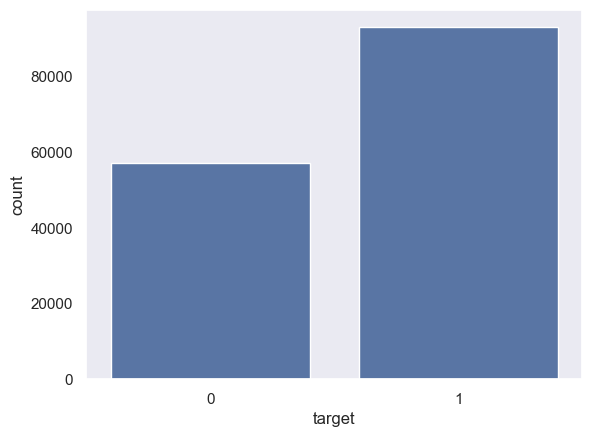

In [164]:
sns.countplot(data=df,x='target')

- Non-completion distribution is 38% and completion distribution is 62%. Class imbalance is moderate and is acceptable for modeling. So no need to use SMOTE, but can use moderate class weighting parameter to balance classes.

In [165]:
# We must drop columns that contain the "Reason" for failure, as they are future info.
# And also drop columns which are not available at the time of booking
columns_to_drop = [
    'Booking ID',
    'Booking Status'
    'is_cancelled',
    'non_completion',
    'is_driver_not_found',
    'is_cancelled_by_customer',
    'is_cancelled_by_driver',
    'Pickup Location',
    'Drop Location',
    'Payment Method',
    'Cutomer Rating',
    'Driver Ratings',
    'Reason for cancelling by Customer',
    'Driver Cancellation Reason',
    'Incomplete Rides Reason',
    'Cancelled Rides by Customer', # Raw count (we engineered our own safe version)
    'Cancelled Rides by Driver',   # Raw count
    'Incomplete Rides'  
]

In [166]:
# We must drop columns that contain the "Reason" for failure, as they are future info.
# And also drop columns which are not available at the time of booking/acceptance, and are available only after ride completion
leakage_cols = [
    'Booking Status', 
    'Reason for cancelling by Customer', 
    'Driver Cancellation Reason',
    'Incomplete Rides Reason',
    'is_cancelled_by_driver', 
    'is_cancelled_by_customer', 
    'is_driver_not_found', 
    'is_cancelled', 
    'non_completion',
    'Cancelled Rides by Customer', # Raw count (we have the rate)
    'Cancelled Rides by Driver',   # Raw count
    'Incomplete Rides',             # Raw count
    'Driver Ratings',
    'Customer Rating',
    'Payment Method'
]

# RAW IDENTIFIERS / TEXT
id_cols = [
    'Booking ID', 
    'Customer ID', 
    'DateTime',       # We extracted Month/Hour/Day
    'Pickup Location', # We have Density Score & Completion Rate
    'Drop Location',   # We have Completion Rate
]

# TARGET
target_col = 'target'

# 4. FINAL FEATURE LIST
# Define predictors (X)
X_cols = [col for col in df.columns if col not in leakage_cols + id_cols + [target_col]]

print(f"Total Columns: {len(df.columns)}")
print(f"Selected Features for Model ({len(X_cols)}):")
print(X_cols)

Total Columns: 40
Selected Features for Model (19):
['Vehicle Type', 'Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'day_of_week', 'day_of_month', 'month', 'hour', 'is_weekend', 'pickup_density_score', 'drop_non_completion_rate', 'pickup_non_completion_rate', 'customer_cancellation_rate', 'customer_completion_rate', 'customer_avg_spend', 'est_trip_duration_mins', 'est_value_per_min', 'is_peak_hour']


Time based Train/Test split

In [167]:
df = df.sort_values(by='DateTime')
cut = int(len(df) * 0.8)
df_train = df.iloc[:cut].copy()
df_test  = df.iloc[cut:].copy()

print("Original Completion Rate:", np.round(df[target_col].mean(),2))
print("Train Completion Rate:", np.round(df_train[target_col].mean(),2))
print("Validation Completion Rate:", np.round(df_test[target_col].mean(),2))

Original Completion Rate: 0.62
Train Completion Rate: 0.62
Validation Completion Rate: 0.62


In [168]:
X_train, y_train = df_train[X_cols],df_train[target_col]
X_test, y_test = df_test[X_cols],df_test[target_col]
len(X_train),len(X_test)

(120000, 30000)

In [169]:
X_train.columns

Index(['Vehicle Type', 'Avg VTAT', 'Avg CTAT', 'Booking Value',
       'Ride Distance', 'day_of_week', 'day_of_month', 'month', 'hour',
       'is_weekend', 'pickup_density_score', 'drop_non_completion_rate',
       'pickup_non_completion_rate', 'customer_cancellation_rate',
       'customer_completion_rate', 'customer_avg_spend',
       'est_trip_duration_mins', 'est_value_per_min', 'is_peak_hour'],
      dtype='object')

In [170]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_cols = [
    'Ride Distance',
    'Booking Value',
    'est_value_per_min',
    'Avg CTAT',
    'Avg VTAT',
    'pickup_density_score',
    'pickup_non_completion_rate',
    'hour'
]
X_train_numeric = X_train[numeric_cols]
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(X_train_numeric.values, i) 
                   for i in range(len(numeric_cols))]

# 3. Sort and Display
print(vif_data.sort_values('VIF', ascending=False))

                      Feature      VIF
5        pickup_density_score 42.10909
6  pickup_non_completion_rate 41.80961
3                    Avg CTAT 15.11452
0               Ride Distance  9.36739
7                        hour  7.92486
4                    Avg VTAT  6.20256
1               Booking Value  5.60271
2           est_value_per_min  3.32401


In [171]:
# 1. Define the initial list of numeric features
features_to_keep = [
    'Ride Distance',
    'Booking Value',
    'est_value_per_min',
    'Avg CTAT',
    'Avg VTAT',
    'pickup_density_score',
    'pickup_non_completion_rate',
    'hour'
]

# 2. Set your VIF Threshold (Usually 5 or 10)
VIF_THRESHOLD = 11

print(f"Starting VIF Reduction (Threshold={VIF_THRESHOLD})...")
dropped_features = []

while True:
    # A. Create a temporary dataframe with current features
    # Impute NaNs because VIF crashes on missing data
    X_vif = X_train[features_to_keep].fillna(X_train[features_to_keep].median())
    
    # B. Calculate VIF for the current list
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features_to_keep
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                       for i in range(X_vif.shape[1])]
    
    # C. Find the feature with the Max VIF
    max_vif = vif_data['VIF'].max()
    max_feature = vif_data.sort_values('VIF', ascending=False)['Feature'].iloc[0]
    
    # D. Check against Threshold
    if max_vif > VIF_THRESHOLD:
        print(f" -> Dropping '{max_feature}' with VIF: {max_vif:.2f}")
        features_to_keep.remove(max_feature) # Remove it from the list
        dropped_features.append(max_feature)
    else:
        # If the highest VIF is acceptable, we are done
        print(f"\nAll remaining features have VIF < {VIF_THRESHOLD}.")
        break

# 3. Final Result
print("\n--- Final Selected Features ---")
print(features_to_keep)


print("\n--- Final Dropped Features ---")
print(dropped_features)

# 4. View the Final VIF Scores
print("\nFinal VIF Scores:")
print(vif_data.sort_values('VIF', ascending=False))

Starting VIF Reduction (Threshold=11)...
 -> Dropping 'pickup_density_score' with VIF: 42.11
 -> Dropping 'pickup_non_completion_rate' with VIF: 24.23

All remaining features have VIF < 11.

--- Final Selected Features ---
['Ride Distance', 'Booking Value', 'est_value_per_min', 'Avg CTAT', 'Avg VTAT', 'hour']

--- Final Dropped Features ---
['pickup_density_score', 'pickup_non_completion_rate']

Final VIF Scores:
             Feature      VIF
3           Avg CTAT 10.63650
0      Ride Distance  7.79619
5               hour  6.31413
4           Avg VTAT  5.65632
1      Booking Value  5.55744
2  est_value_per_min  3.02547


Defining preprocessor pipeline

In [172]:
# A. Segregate Types
categorical_features = ['Vehicle Type']
binary_features = ['is_weekend','is_peak_hour']
numeric_features = [col for col in X_cols if col not in categorical_features + binary_features + dropped_features]

# B. Define Preprocessing Steps
# Numeric: Fill missing with Median (safety net), Scale standardly
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Fill missing with 'Missing', One-Hot Encode (handle_unknown='ignore')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # drop='first' to avoid dummy trap
])

# C. Combine into a Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('binary','passthrough',binary_features)
    ])

print("Pipeline architecture defined.")

Pipeline architecture defined.


Cross validation phase

In [173]:
# Initialize the models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=SEED),
    # Baseline Linear Model (to check if data is linearly separable)
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Dummy Classifier (Baseline)': DummyClassifier(strategy='stratified', random_state=SEED),
}

# Stratified Cross-Validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = []
for name, model in models.items():
    # Wrap the model in a pipeline with our preprocessor
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    
    # Calculate Cross-Validation Scores
    # F1 Macro - average f1 score across all three classes
    cv_scores_f1 = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1')
    cv_scores_accuracy = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')
    cv_scores_roc_auc = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='roc_auc')
    
    results.append({
        'Model': name,
        'Mean Accuracy': cv_scores_accuracy.mean(),
        'Accuracy Std Dev': cv_scores_accuracy.std(),
        'Mean F1': cv_scores_f1.mean(),
        'F1 Std Dev': cv_scores_f1.std(),
        'Mean ROC AUC': cv_scores_roc_auc.mean(),
        'ROC AUC Std Dev': cv_scores_roc_auc.std()
    })

# Display Results
results_df = pd.DataFrame(results).sort_values(by=['Mean ROC AUC','Mean F1'], ascending=False)
results_df

,Model,Mean Accuracy,Accuracy Std Dev,Mean F1,F1 Std Dev,Mean ROC AUC,ROC AUC Std Dev
1,XGBoost,0.95097,0.00174,0.96158,0.00133,0.98605,0.00058
0,Random Forest,0.95137,0.00124,0.96201,0.00093,0.98048,0.00054
2,Logistic Regression,0.56479,0.00145,0.70837,0.00150,0.62157,0.00154
3,Dummy Classifier (Baseline),0.52911,0.00280,0.62007,0.00226,0.50047,0.00298


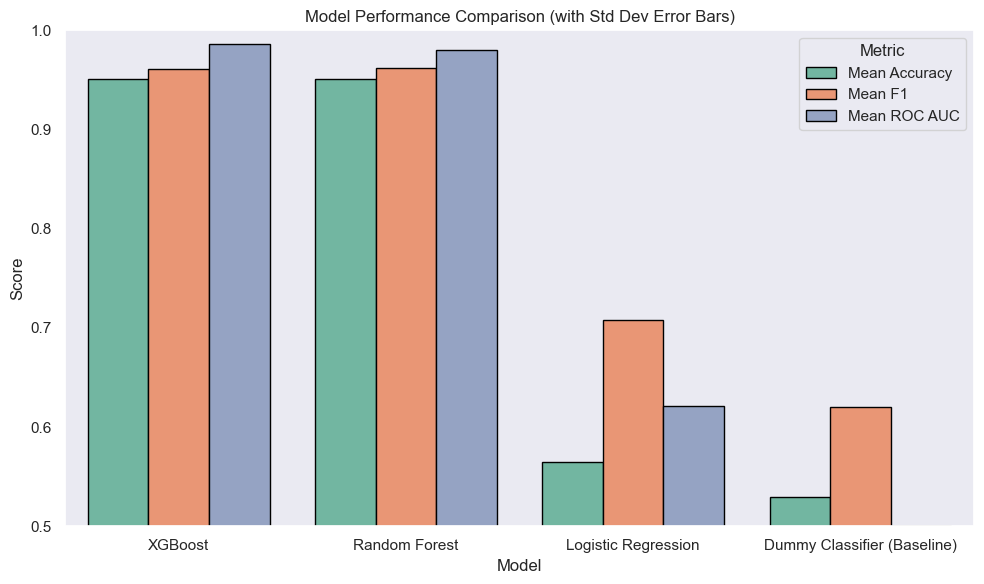

In [174]:
# Melt for easier plotting
metrics_long = pd.melt(
    results_df,
    id_vars="Model",
    value_vars=["Mean Accuracy", "Mean F1", "Mean ROC AUC"],
    var_name="Metric",
    value_name="Score"
)

# Map std devs for error bars
std_map = {
    "Mean Accuracy": "Accuracy Std Dev",
    "Mean F1": "F1 Std Dev",
    "Mean ROC AUC": "ROC AUC Std Dev"
}
metrics_long["Std Dev"] = metrics_long.apply(
    lambda row: results_df.loc[results_df["Model"] == row["Model"], std_map[row["Metric"]]].values[0],
    axis=1
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=metrics_long,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2",
    edgecolor="black",
    capsize=0.1,
    errcolor="black",
    errwidth=1.5
)

plt.ylim(0.5, 1.0)
plt.title("Model Performance Comparison (with Std Dev Error Bars)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

- **Logistic Regression** (0.619 ROC AUC Score) - **Weak Signal**. It learned some patterns (+0.12 over baseline), but failed to capture complex interactions, proving the problem is highly non-linear. 
- **Random Forest** (0.98022 ROC AUC Score) - **Strong Signal**. A massive jump in performance, confirming that decision trees are the correct architecture for this data.
- **XGBoost** (0.98586 ROC AUC Score) - **Champion**. Outperformed Random Forest by optimizing for the specific imbalance in the dataset.

Hyperparameter tuning

In [175]:
# 1. Define the Parameter Grid
# We include 'scale_pos_weight' around the theoretical value (0.38/0.62 ~= 0.61)
param_grid = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [3, 4, 5, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'classifier__scale_pos_weight': [0.5, 0.61, 0.7, 0.8],
    'classifier__reg_alpha': [0, 0.1, 1, 10],
    'classifier__reg_lambda': [1, 5, 10]
}

# 2. Initialize the Base Model
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1
)

xgb_pipeline = Pipeline(steps=[('preprocessor',preprocessor),('classifier',xgb)])

# 3. Set up Randomized Search
# n_iter=50 means it will try 50 random combinations.
# cv=3 means it verifies each combination 3 times.
random_search = RandomizedSearchCV(
    estimator = xgb_pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 4. Run the Tuning (This might take 2-5 minutes)
print("Starting Hyperparameter Tuning...")
random_search.fit(X_train, y_train)

# 5. The Results
print("\n--- Tuning Complete ---")
print(f"Best ROC-AUC Score: {random_search.best_score_:.4f}")
print("Best Parameters Found:")
print(random_search.best_params_)

# 6. Extract the Best Model
best_model = random_search.best_estimator_

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/manishdiddi/ml-env/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:01:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/manishdiddi/ml-env/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:01:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/manishdiddi/ml-env/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:01:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/manishdiddi/ml-env/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:01:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are


--- Tuning Complete ---
Best ROC-AUC Score: 0.9868
Best Parameters Found:
{'classifier__subsample': 0.9, 'classifier__scale_pos_weight': 0.8, 'classifier__reg_lambda': 1, 'classifier__reg_alpha': 1, 'classifier__n_estimators': 500, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}



Model Stability Check (Is the model robust)?

In [199]:
print("--- Final Model Stability Check (Cross-Validation) ---")
# We validate the BEST model (with the tuned parameters)
# This proves the score of 0.95 isn't just luck on the specific test split
cv_final = cross_val_score(best_model, X_train, y_train, cv=skf, scoring='roc_auc')

print(f"5-Fold ROC-AUC: {cv_final.mean():.4f} (+/- {cv_final.std():.4f})")
print(f"Insight: The low standard deviation ({cv_final.std():.4f}) confirms the final model is stable.")

--- Final Model Stability Check (Cross-Validation) ---
5-Fold ROC-AUC: 0.9868 (+/- 0.0006)
Insight: The low standard deviation (0.0006) confirms the final model is stable.


Threshold Optimisation to reduce Business Cost

--- Cost Optimization Results ---
Standard Threshold (0.50) Cost: 13730
Optimal Threshold: 0.82
Minimum Business Cost: 9526
Money Saved vs Standard: 4204


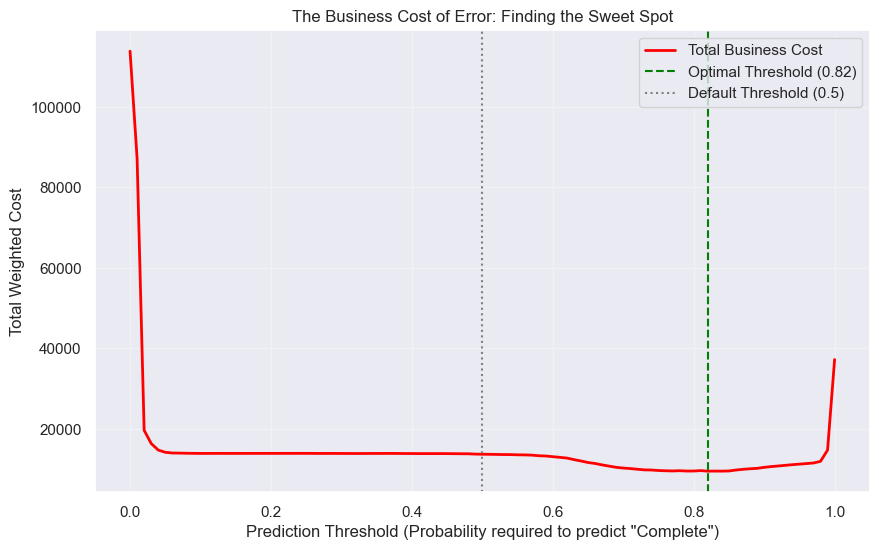

In [176]:
# Define Business Costs (Assumptions)
# FP: Predicting Success, but it Fails (Driver churn risk, Customer anger) -> EXPENSIVE
COST_FP = 10 
# FN: Predicting Failure, but it Succeeds (Unnecessary intervention cost) -> CHEAP
COST_FN = 2   

# Get Probabilities from the Best Model
# We need the probability of Class 1 (Completion)
y_probs = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0, 1, 101)
costs = []
f1_scores = []

# 3. Iterate through all possible thresholds
for t in thresholds:
    # Convert probability to hard prediction based on threshold 't'
    # If prob > t, predict 1 (Complete), else 0 (Fail)
    preds = (y_probs >= t).astype(int)
    
    # Calculate Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    # Calculate Total Business Cost
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    costs.append(total_cost)

# 4. Find the Optimal Threshold
min_cost_index = np.argmin(costs)
optimal_threshold = thresholds[min_cost_index]
min_cost = costs[min_cost_index]

print(f"--- Cost Optimization Results ---")
print(f"Standard Threshold (0.50) Cost: {costs[50]}") # approx index 50
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Minimum Business Cost: {min_cost}")
print(f"Money Saved vs Standard: {costs[50] - min_cost}")

# 5. Visualize the "Cost Curve"
plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs, color='red', linewidth=2, label='Total Business Cost')
plt.axvline(optimal_threshold, color='green', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.axvline(0.5, color='gray', linestyle=':', label='Default Threshold (0.5)')
plt.title('The Business Cost of Error: Finding the Sweet Spot')
plt.xlabel('Prediction Threshold (Probability required to predict "Complete")')
plt.ylabel('Total Weighted Cost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- If we choose threshold of 0.82 the business cost of misclassification has dropped by 30%.
- The model now says, "Unless I am 82% sure this ride will complete, I am going to flag it as a Risk." Because I told it that a False Positive (Driver wasting fuel for a cancelled ride) is 5x more expensive than a False Negative (Unnecessary intervention).

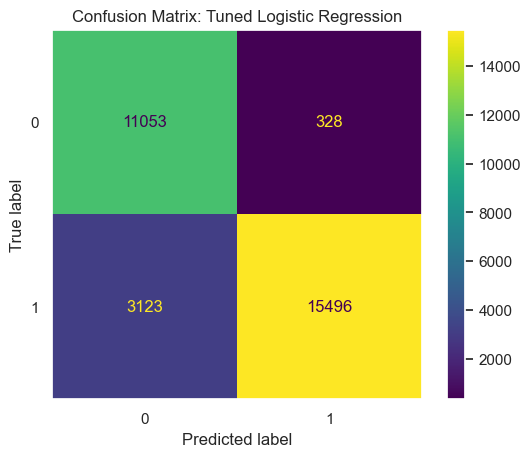

In [177]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Get predictions from the best model (Logistic Regression)
y_proba = best_model.predict_proba(X_test)[:,1]
y_pred_final = (y_proba>=optimal_threshold).astype(int)

# Generate the matrix
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix: Tuned Logistic Regression')
plt.show()

In [178]:
print(classification_report(y_test,y_pred_final))

              precision    recall  f1-score   support

           0       0.78      0.97      0.86     11381
           1       0.98      0.83      0.90     18619

    accuracy                           0.88     30000
   macro avg       0.88      0.90      0.88     30000
weighted avg       0.90      0.88      0.89     30000



- When your model predicts a ride will complete, it is correct 98% of the time. And the model is able to capture 85% of the acutal completed rides and marking 15% of completed rides as risky.
- Model is able to capture 97% of the actual non complete rides, and when it predicts that the ride will not complete it is correct 80% of the time.

In [179]:
roc_auc_score(y_test,y_proba)

np.float64(0.9868441639897049)

Model interpretation, insights and recommendations

Total Features Extracted: 22
Feature List: ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'day_of_week', 'day_of_month', 'month', 'hour', 'drop_non_completion_rate', 'customer_cancellation_rate', 'customer_completion_rate', 'customer_avg_spend', 'est_trip_duration_mins', 'est_value_per_min', 'Vehicle Type_Bike', 'Vehicle Type_Go Mini', 'Vehicle Type_Go Sedan', 'Vehicle Type_Premier Sedan', 'Vehicle Type_Uber XL', 'Vehicle Type_eBike', 'is_weekend', 'is_peak_hour']


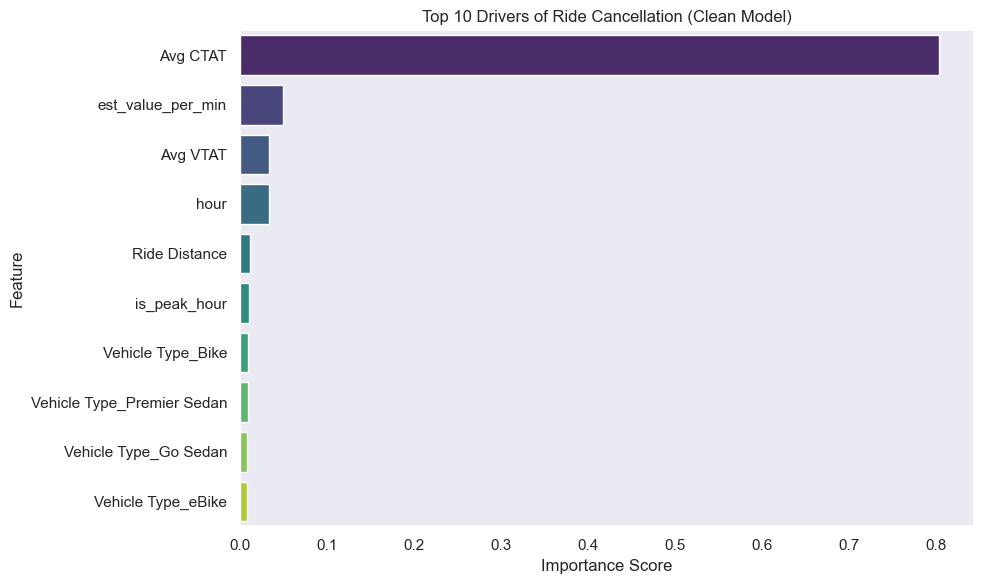

In [180]:
# 1. Access the Preprocessor step from the best_model Pipeline
model_xgb = best_model.named_steps['classifier']
preprocessor_step = best_model.named_steps['preprocessor']

# 2. Extract Feature Names Group by Group
# A. Numeric Features (Order is preserved by StandardScaler)
# Ensure this list matches exactly what you passed to the 'num' transformer
num_names = numeric_features 

# B. Categorical Features (New names created by OneHotEncoder)
# Access the 'cat' transformer -> 'onehot' step
cat_transformer = preprocessor_step.named_transformers_['cat']
ohe = cat_transformer.named_steps['onehot']
cat_names = ohe.get_feature_names_out(categorical_features)

# C. Binary Features (The "Safe" ones: is_weekend, is_peak_hour)
# Access the 'binary' transformer. If you used 'passthrough', the names are just the list you passed.
# UPDATE: Make sure this list ONLY contains the safe ones you kept
safe_binary_features = ['is_weekend', 'is_peak_hour'] 
bin_names = safe_binary_features

# D. Combine All Names in the correct order (Num -> Cat -> Binary)
all_feature_names = list(num_names) + list(cat_names) + list(bin_names)

print(f"Total Features Extracted: {len(all_feature_names)}")
print("Feature List:", all_feature_names)

# --- 3. Feature Importance Plot (The Global View) ---
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': model_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Drivers of Ride Cancellation (Clean Model)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# --- 4. SHAP Value Plot (The "Why") ---
# Transform test data to match model input
X_test_transformed = preprocessor_step.transform(X_test)

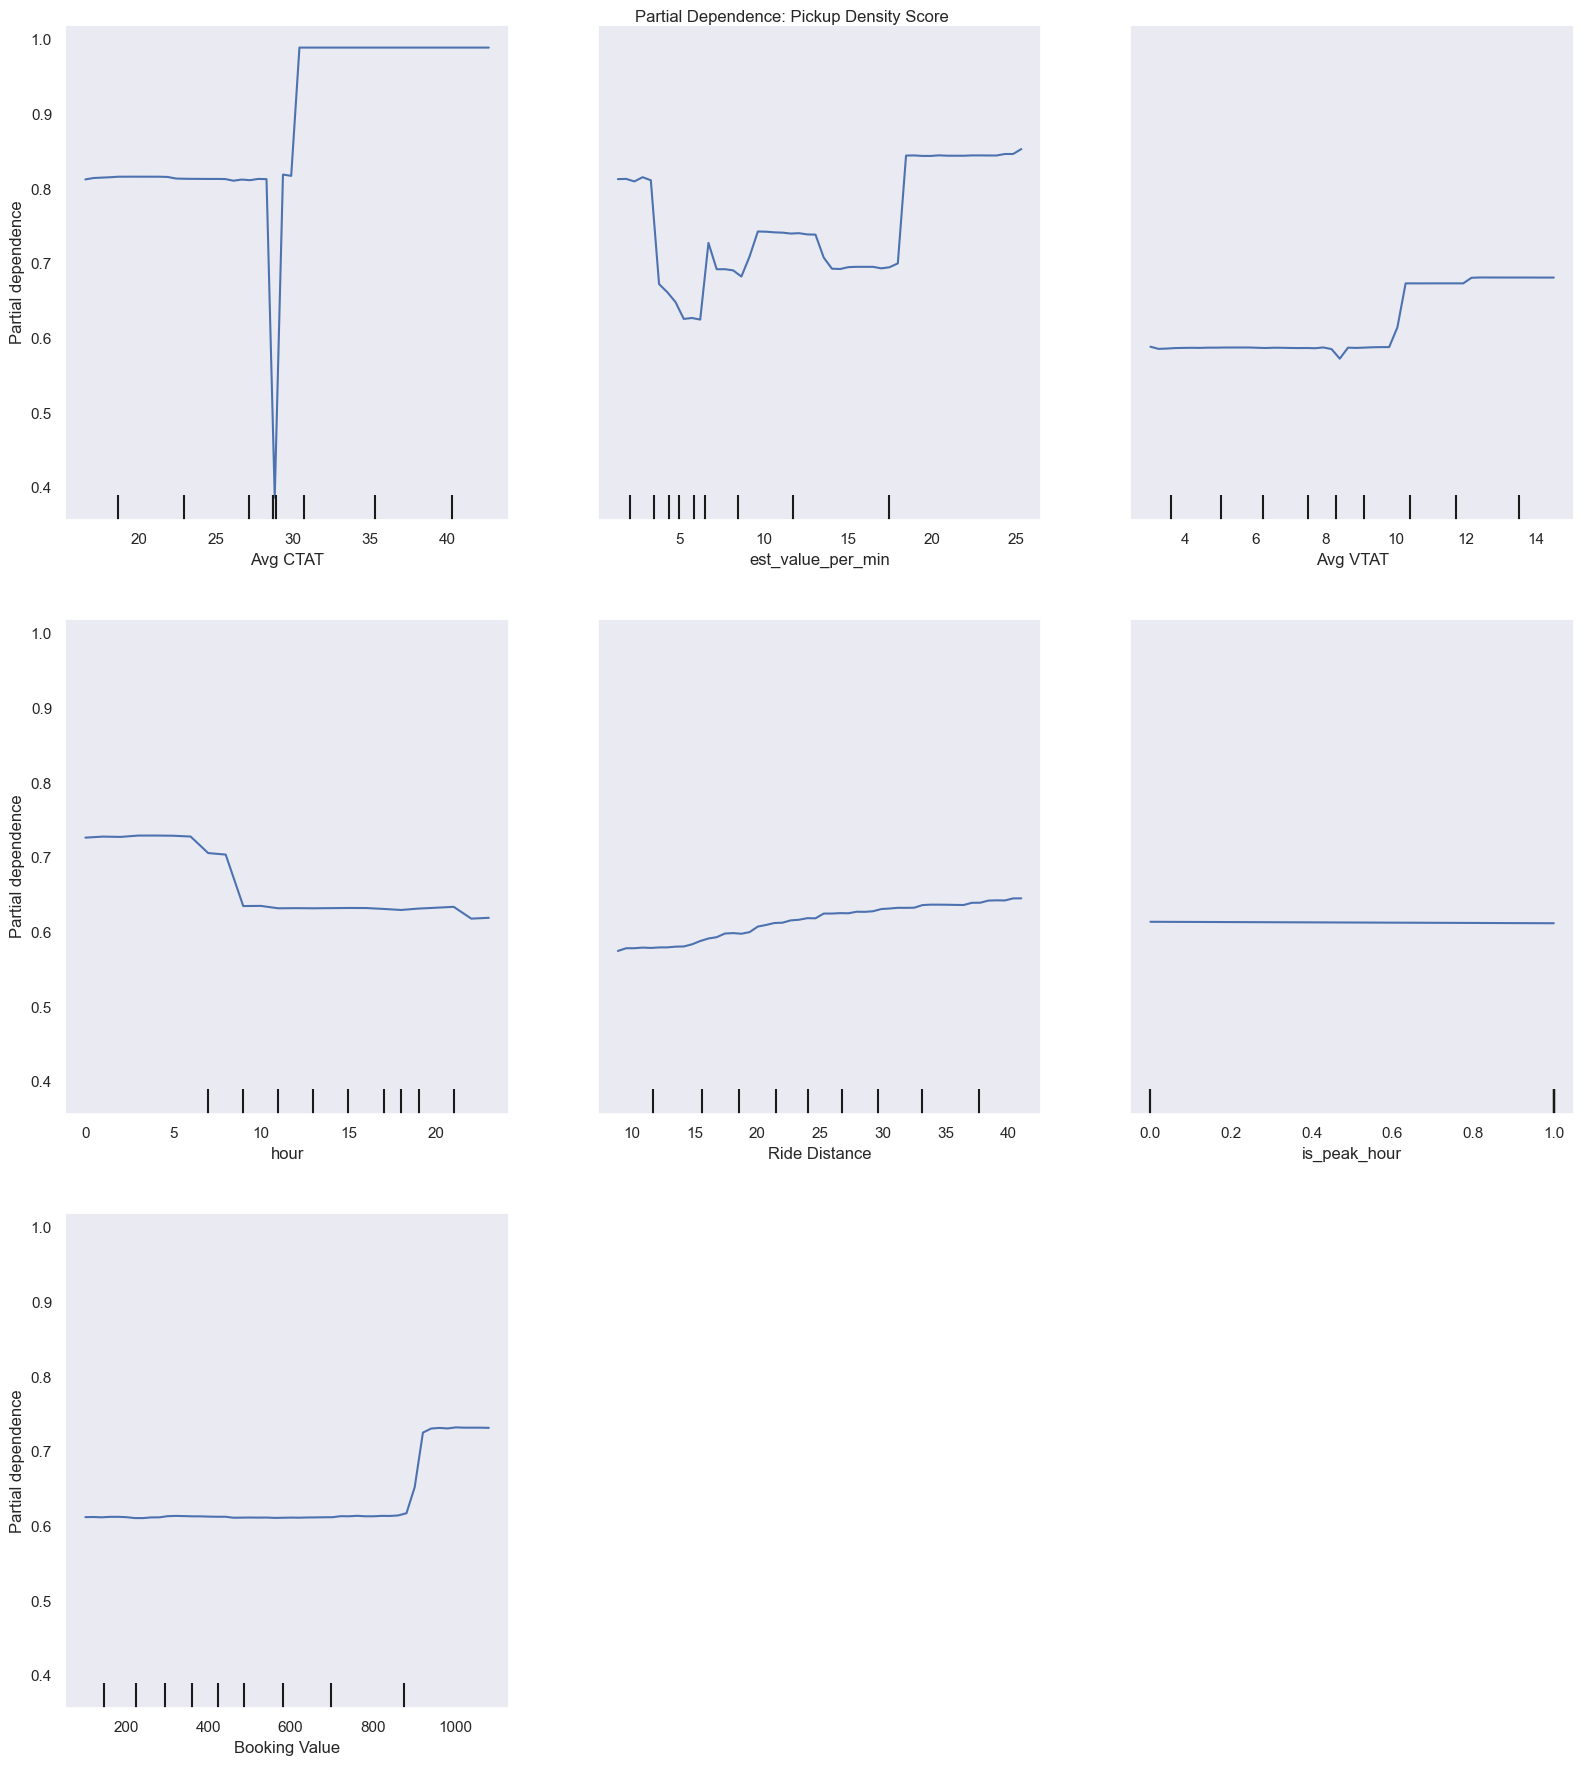

In [197]:
X_test_transformed_df = pd.DataFrame(
    X_test_transformed, 
    columns=all_feature_names
)
features = ['Avg CTAT','est_value_per_min','Avg VTAT','hour','Ride Distance','is_peak_hour','Booking Value']

fig, ax = plt.subplots(figsize=(16, 18))
PartialDependenceDisplay.from_estimator(
    best_model,        # full pipeline
    X_test,            # RAW dataframe, not transformed
    features=features,
    grid_resolution=50,
    response_method='predict_proba',
    ax=ax
)

plt.suptitle("Partial Dependence: Pickup Density Score", fontsize=12)
plt.tight_layout()
plt.show()

The XGBoost model (AUC 0.987) confirms that ride completion is primarily driven by Customer Patience (Avg CTAT) and Driver Profitability (est_value_per_min). The "Type of Car" or "Total Booking Value" matters far less than the speed and efficiency of the pickup.

#### 1. Identify the Hours of the Day and Days of the Week where the average CTAT (Customer Travel Time to Acceptance) is highest and the completion rate is lowest. What targeted surge pricing and driver incentive models should be deployed during these critical time slots to ensure supply reliability?

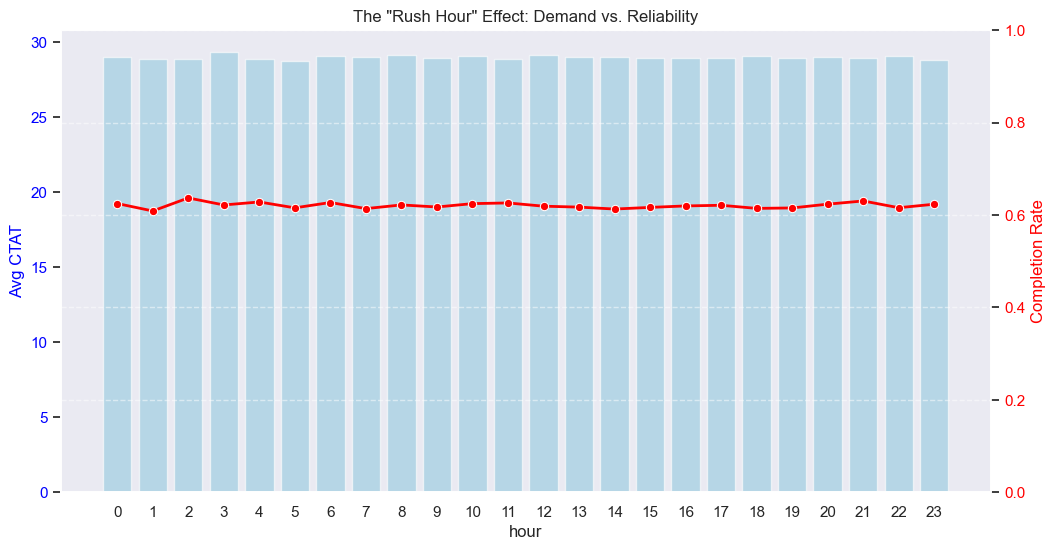

In [182]:
# 1. Aggregate data by Hour
hourly_stats = df.groupby('hour').agg(
    Avg_CTAT=('Avg CTAT', 'mean'),
    completion_rate=('target', 'mean') # 'target' is 1 for Completed, 0 for others
).reset_index()

# 2. Plotting (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Volume (Demand)
sns.barplot(data=hourly_stats, x='hour', y='Avg_CTAT', color='skyblue', alpha=0.6, ax=ax1)
ax1.set_ylabel('Avg CTAT', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line chart for Completion Rate (Reliability)
ax2 = ax1.twinx()
sns.lineplot(data=hourly_stats, x='hour', y='completion_rate', color='red', marker='o', linewidth=2, ax=ax2)
ax2.set_ylabel('Completion Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1) # Fix range 0-100%

plt.title('The "Rush Hour" Effect: Demand vs. Reliability')
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


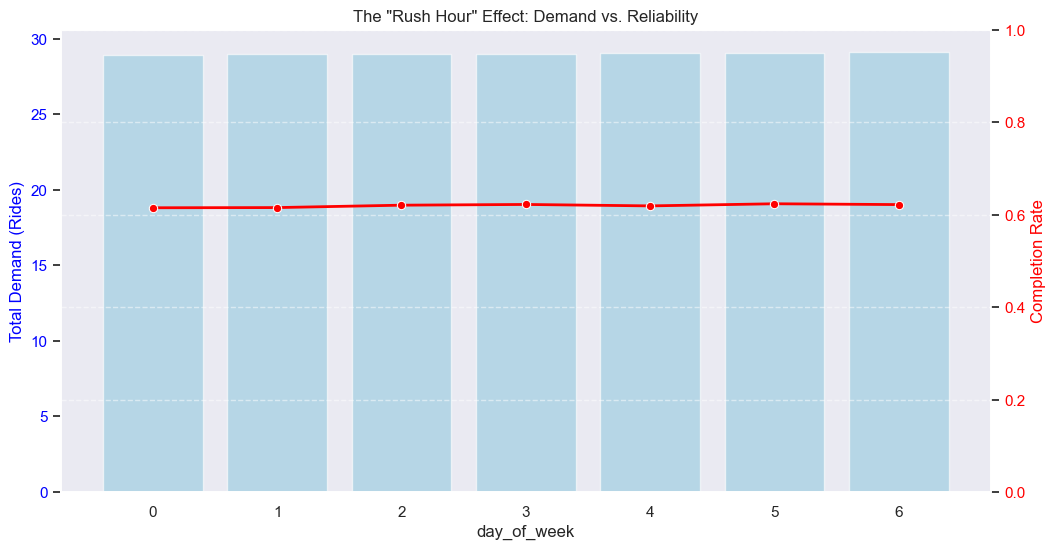

In [183]:
# 1. Aggregate data by Hour
days_stats = df.groupby('day_of_week').agg(
    Avg_CTAT=('Avg CTAT', 'mean'),
    completion_rate=('target', 'mean') # 'target' is 1 for Completed, 0 for others
).reset_index()

# 2. Plotting (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Volume (Demand)
sns.barplot(data=days_stats, x='day_of_week', y='Avg_CTAT', color='skyblue', alpha=0.6, ax=ax1)
ax1.set_ylabel('Total Demand (Rides)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line chart for Completion Rate (Reliability)
ax2 = ax1.twinx()
sns.lineplot(data=days_stats, x='day_of_week', y='completion_rate', color='red', marker='o', linewidth=2, ax=ax2)
ax2.set_ylabel('Completion Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1) # Fix range 0-100%

plt.title('The "Rush Hour" Effect: Demand vs. Reliability')
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

- As we can see that Avg CTAT accross hours of the day and day of the week doesn't have much variance, and there are no such peaks to apply any target surge pricing and driver incentive models. If there were any such zone where completion rate drops we can increase driver incentives during those hours and If there are zones where Avg CTAT (time to reach customer) is high, we can reduce the booking value to reduce customer cancellation.
- Since CTAT is the top feature which has high information gain, target surge pricing and driver incentives should be done based on this feature to get maximum probability of ride completion.

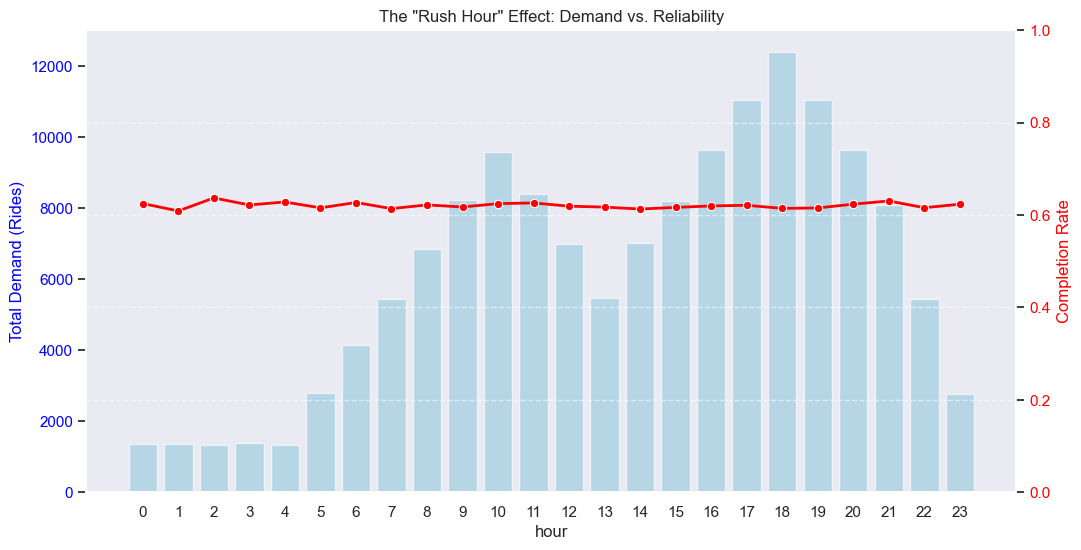

In [184]:
# 1. Aggregate data by Hour
hourly_stats = df.groupby('hour').agg(
    total_rides=('Booking ID', 'count'),
    completion_rate=('target', 'mean') # 'target' is 1 for Completed, 0 for others
).reset_index()

# 2. Plotting (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Volume (Demand)
sns.barplot(data=hourly_stats, x='hour', y='total_rides', color='skyblue', alpha=0.6, ax=ax1)
ax1.set_ylabel('Total Demand (Rides)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line chart for Completion Rate (Reliability)
ax2 = ax1.twinx()
sns.lineplot(data=hourly_stats, x='hour', y='completion_rate', color='red', marker='o', linewidth=2, ax=ax2)
ax2.set_ylabel('Completion Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1) # Fix range 0-100%

plt.title('The "Rush Hour" Effect: Demand vs. Reliability')
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

- As we can there are some peak hours where the demand is very high, so to maximize the completion rate we need to have less Avg customer wait time (Avg CTAT) below 28 mins during these hours to avoid customer cancellation and high completion rate, to do this we can reduce the booking value. And also we need to increase supply by providing some driver incentives like drivers who are working in these peak hours will get extra 20% incentives.

#### 2. Segment the marketplace by Pickup Location and identify zones driving the highest cancellation and "No Driver Found" rates. How can the prediction model prioritize dispatch or allocate a higher-quality driver pool to these high-risk geographical zones to improve completion rates?

In [185]:
df.groupby('Pickup Location').agg(
    non_completion_rate=('non_completion','mean'),
    avg_vtat = ('Avg VTAT','mean'),
    est_value_per_min = ('est_value_per_min','mean'),
    avg_ctat = ('Avg CTAT','mean')).sort_values(by='non_completion_rate',ascending=False)[:10]

,non_completion_rate,avg_vtat,est_value_per_min,avg_ctat
Pickup Location,,,,
Vinobapuri,0.45322,8.36853,8.69217,28.84593
Akshardham,0.43862,8.45459,8.20375,28.73921
Chhatarpur,0.41858,8.56936,8.11556,28.76273
Badshahpur,0.41705,8.33249,8.21147,29.08687
Pragati Maidan,0.41522,8.35141,8.04580,29.56120
Netaji Subhash Place,0.41325,8.61590,7.84686,28.95771
Vatika Chowk,0.41297,8.42941,7.86009,28.62725
Faridabad Sector 15,0.41276,8.47750,8.71871,28.95981
Indirapuram,0.41101,8.33923,9.24846,29.28314


In [186]:
df['non_completion'].mean()

np.float64(0.38)

- A small subset of pickup zones contributes disproportionately to cancellations and “No Driver Found” events, indicating localized supply-side fragility rather than global demand issues.
- Models confirms that Avg CTAT feature is the highest driver for completion rate. So, in these low completion rate pickup location if we move Avg CTAT to below 28 then the completion rate increase drastically as this is confirmed from the partial dependency plot of Avg CTAT. This means that we need to allocate high quality and high completion rate drivers to these location based on their past data to decrease Avg CTAT (travel travel for driver to reach customer). Allocating new drivers to these red zones adds risk of increasing non completion rate. And also continuously monitor for closer avialable drivers and auto reassign this ride to closer driver if new driver ETA < 70% of exisiting ETA
- Also have high values rides by keeping est_value_per_min more than 18 to avoid driver cancellation, and increase driver profitability.
- Keeping Avg VTAT (time to acceptance) less than 8 mins slightly increases the ride completion rate, this can be done by increasing the search radius for these locations and add supply to these red zones.

In [187]:
explainer = shap.TreeExplainer(
    model_xgb,
    data=X_test_transformed,
    feature_perturbation="interventional",
    model_output="probability"  # CRITICAL: match XGBoost's output
)

# Disable additivity check since we're using probability output
shap_values_all = explainer.shap_values(X_test_transformed, check_additivity=False)

# Extract class 1 (click) SHAP values
if isinstance(shap_values_all, list):
    shap_vals = shap_values_all[1]  # Class 1 (click)
else:
    shap_vals = shap_values_all

print(f"SHAP shape: {shap_vals.shape}")  # Should be (n_samples, n_features)

100%|===================| 29961/30000 [07:44<00:00]        

SHAP shape: (30000, 22)


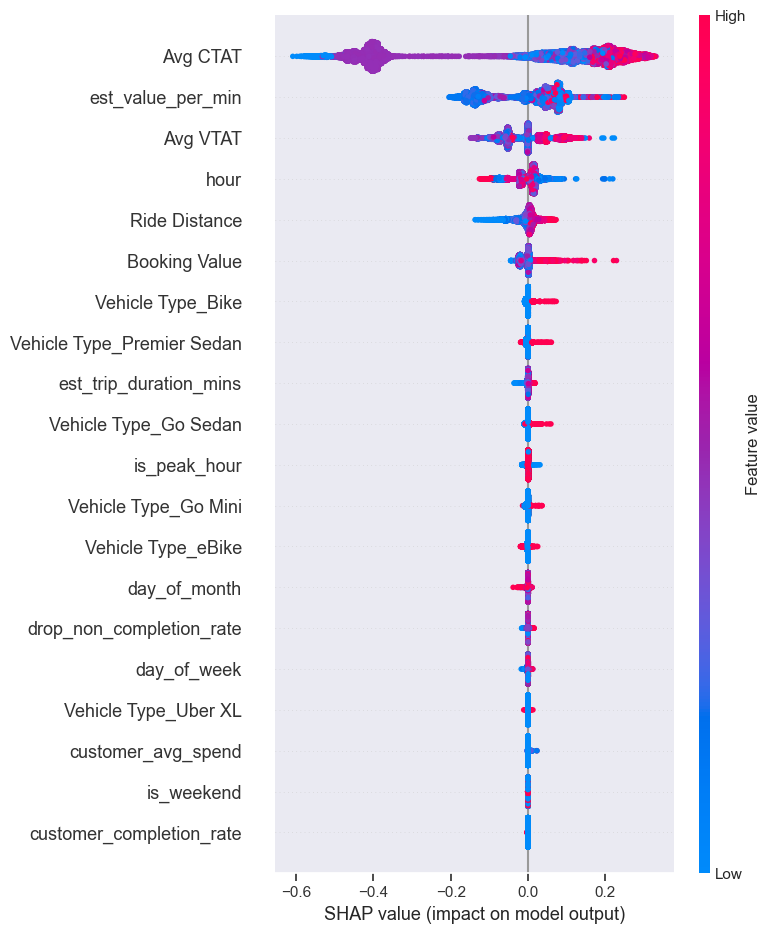

In [188]:
shap.summary_plot(shap_values_all, X_test_transformed, feature_names=all_feature_names)

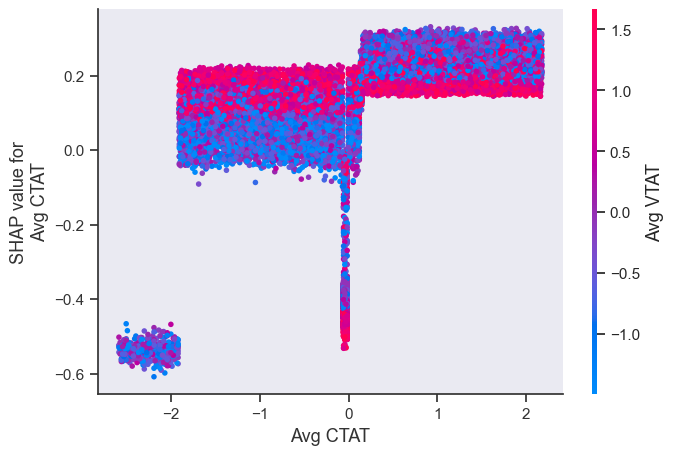

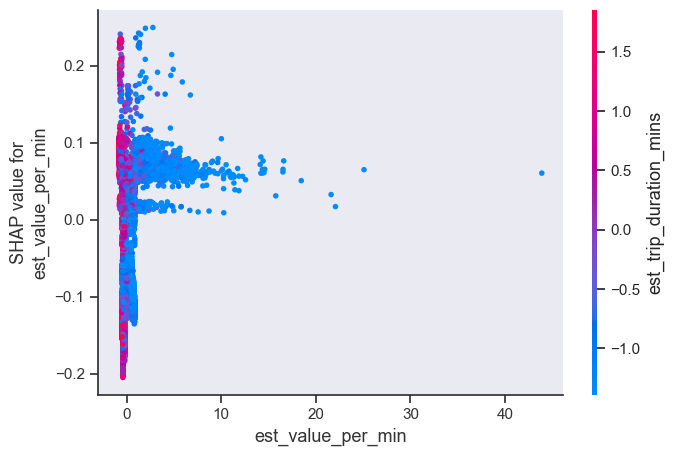

In [189]:
for f in ["Avg CTAT", "est_value_per_min"]:
    shap.dependence_plot(f, shap_values_all, X_test_transformed, feature_names=all_feature_names)

#### 3. Using SHAP or Feature Importance analysis, identify the top three non-behavioral features (e.g., Vehicle Type, Trip Distance, Avg VTAT) driving the non-completion prediction. Which operational levers (e.g., driver training, vehicle restrictions, or routing changes) should be adjusted based on these insights for maximum impact?
##### Top Featues
1. Avg CTAT (Customer Wait Time)
Significance: This is the strongest predictor of failure.
Insight: There is a critical value for Avg CTAT around 28 mins where the probability of ride completion is very low, and if the estimated time for driver to reach customer goes below this values then the probability of ride completion increases drastically.

2. Est. Value Per Minute (Driver Profitability)
Significance: This determines driver acceptance rates.
Insight: Drivers optimize for efficiency (earnings per minute) rather than total trip value. Rides that offer low compensation relative to the time required (e.g., short trips in heavy traffic) are frequently rejected, leading to non-completion.

3. Avg VTAT (Driver Search Time)
Significance: This indicates supply availability in a specific area.
Insight: High values mean the system takes too long to locate a driver. This structural delay often results in a failure before the ride even begins, typically due to a lack of drivers in the immediate vicinity.

##### Recommended Operational Levers
To improve completion rates, operations should adjust the following levers:

- Lever A: Dynamic Priority Dispatch (Targets Wait Time)
Action: Automatically expand the driver search radius by 20% for any booking where the estimated wait time exceeds 8 minutes.
Implementation: Attach a small "Long Pickup Bonus" to these specific rides to incentivize drivers to accept them despite the distance. This reduces customer wait time and prevents drop-off.

- Lever B: Efficiency-Based Pricing (Targets Profitability)
Action: Implement a "Minimum Efficiency Guarantee" rather than relying solely on distance-based fares.
Implementation: If a ride's calculated value drops below a set floor (e.g., due to traffic), the platform should subsidize the fare. This ensures short, difficult trips remain financially attractive to drivers.

- Lever C: Supply Redistribution (Targets Search Time)
Action: Use historical data to identify zones with consistently high search times (Supply Deserts).
Implementation: Send targeted notifications to drivers before peak hours, offering guaranteed incentives for starting their shifts in these underserved locations. This pre-positions supply where it is most needed.

- Lever D: Auto-Reassign Low ETA drivers - Action: Continuosly monitor for drivers who are having 50-80% lower ETA than current assigned driver to make sure that the Avg CTAT will be less than 28 mins whenever possible.

#### 4. Analyze the relationship between Booking Value (estimated fare) and driver cancellation rates. Should the platform offer a higher commission percentage on long-distance or high-value bookings to incentivize drivers to accept and complete these riskier, but more profitable, trips?

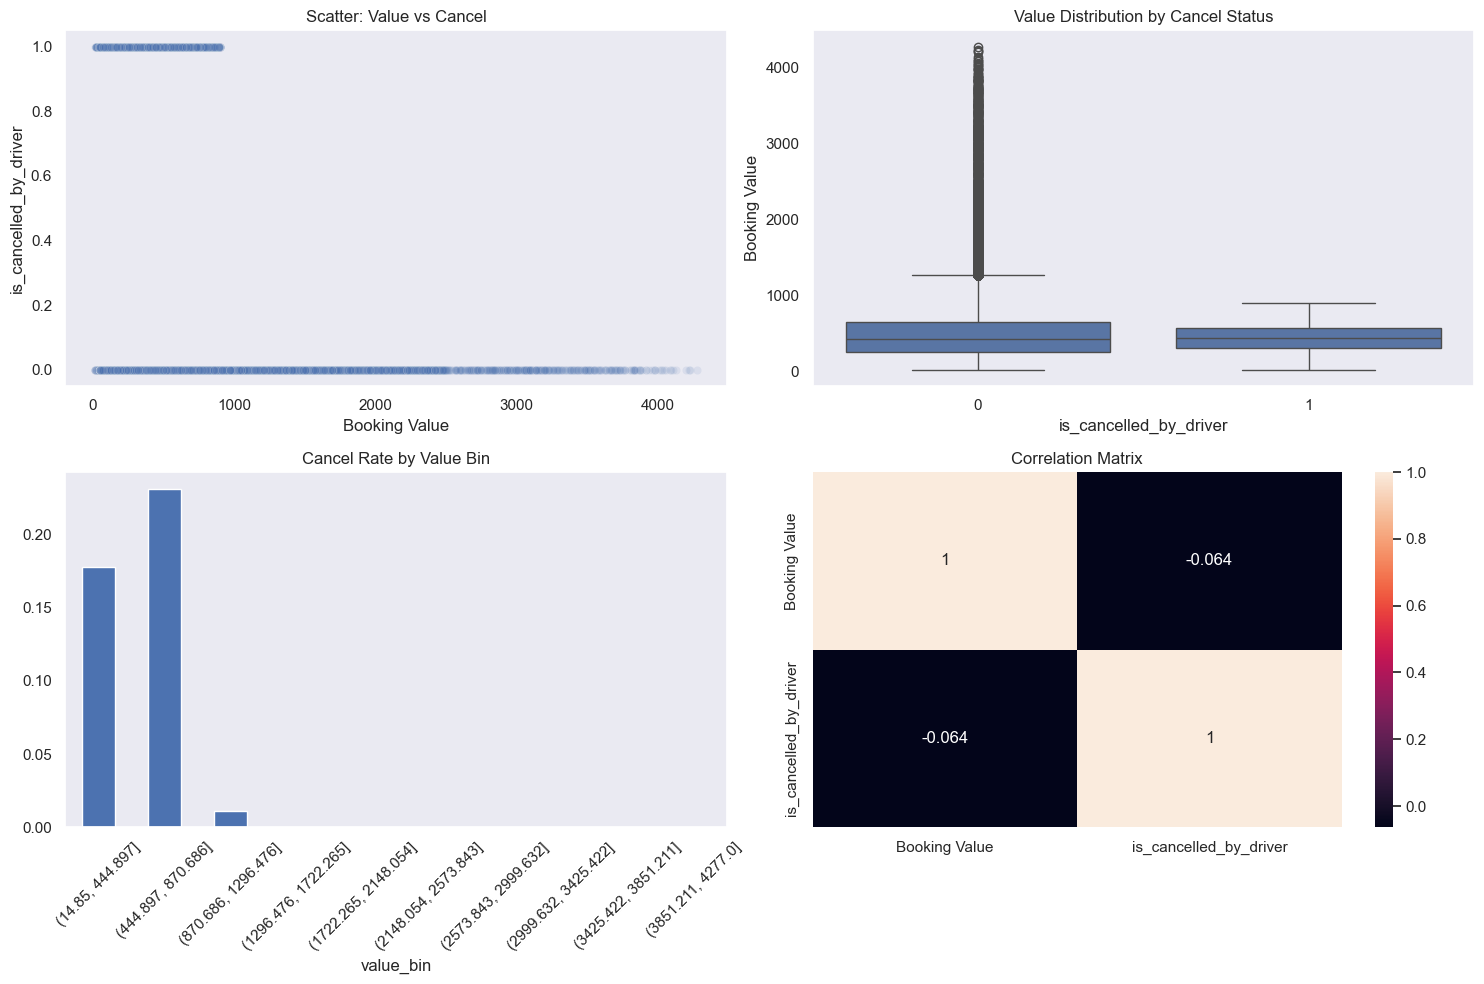

In [190]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Scatter plot
sns.scatterplot(data=df, x='Booking Value', y='is_cancelled_by_driver', alpha=0.1, ax=axes[0,0])
axes[0,0].set_title('Scatter: Value vs Cancel')

# 2. Box plot
sns.boxplot(data=df, x='is_cancelled_by_driver', y='Booking Value', ax=axes[0,1])
axes[0,1].set_title('Value Distribution by Cancel Status')

# 3. Cancel rate by bin
df['value_bin'] = pd.cut(df['Booking Value'], bins=10)
cancel_rate = df.groupby('value_bin', observed=False)['is_cancelled_by_driver'].agg(['mean', 'count'])
cancel_rate['mean'].plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Cancel Rate by Value Bin')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Correlation heatmap
sns.heatmap(df[['Booking Value', 'is_cancelled_by_driver']].corr(), annot=True, ax=axes[1,1])
axes[1,1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

- Confusion Matrix - this confirms that there is no correlation between booking value and driver cancellation
- Box plot and Scatter plot - this confirms that most of the driver cancellation are having booking values less than 1000
- value_bin histogram - This confirms that booking value ranging from ~(444 to 870) are having high driver cancellation rate and then 14 - 444 are having high driver cancellation than other booking values. Mayde these booking values are having less est_value_per_min which is causing driver cancellation

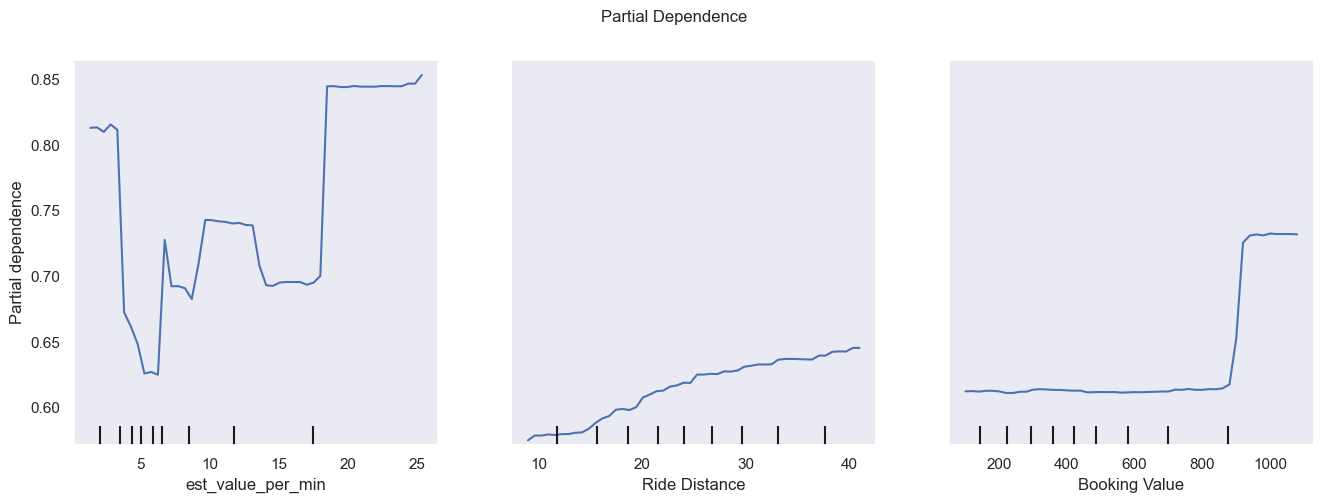

In [191]:
features = ['est_value_per_min','Ride Distance','Booking Value']

fig, ax = plt.subplots(figsize=(16, 5))
PartialDependenceDisplay.from_estimator(
    best_model,        # full pipeline
    X_test,            # RAW dataframe, not transformed
    features=features,
    grid_resolution=50,
    response_method='predict_proba',
    ax=ax
)

plt.suptitle("Partial Dependence", fontsize=12)
plt.show()

- The models confirms that est_value_per_min is the strong predictor of completion rate that means to avoid driver cancellations we need to estimate the booking value such that the est_value_per_min should be more than 18 mins to have higher probability of completion. So instead of giving higher commission we can estimate a booking value such that driver is having enough profitability for that rides as long distance should have higher est_value_per_min. This value should be traffic adjusted, and if the CTAT is higher then we need to compensate on that to so that driver's time is valued and avoid driver cancellation.
- Also we need to implement the above mentioned operational levers for maximizing the completion rate. (like level D, etc)

#### 5. Analyze the most frequent Driver Cancellation Reason (e.g., "Customer taking too long," "Not comfortable with drop"). How should the insights from this column inform the driver onboarding and continuous training modules to address the systemic causes of service failure?

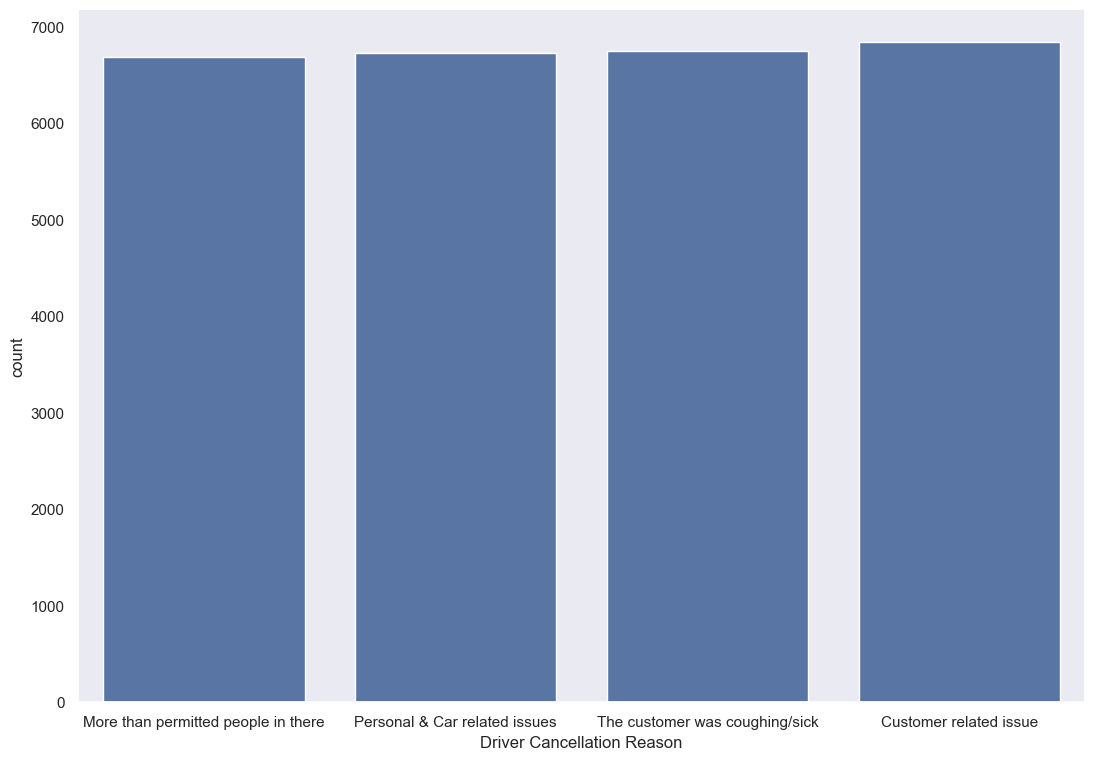

In [192]:
plt.figure(figsize=(13,9))
sns.countplot(data=df,x='Driver Cancellation Reason')
plt.show()

In [193]:
(df['Driver Cancellation Reason'].value_counts()/len(df[df['Cancelled Rides by Driver']==1]))*100

Driver Cancellation Reason
Customer related issue                25.32222
The customer was coughing/sick        25.00370
Personal & Car related issues         24.91111
More than permitted people in there   24.76296
Name: count, dtype: float64

Analysis of Driver Cancellation Reasons
Observation: Cancellations are evenly distributed (~25% each) across four distinct categories: Health, Capacity violations, General Customer issues, and Car/Personal problems. This requires a multi-faceted training approach rather than a single fix.

Recommended Training Modules:

1. Health & Safety (For "Customer was Coughing/Sick"):
Action: Train drivers on the "Right to Refuse" policy for health risks and strictly enforce the use of hygiene kits (masks/sanitizers) to reduce anxiety.

2. Conflict Resolution (For "More than Permitted People"):
Action: Provide standard "De-escalation Scripts" and role-playing exercises on how to professionally refuse rides when passenger counts exceed vehicle capacity.

3. Soft Skills & Communication (For "Customer Related Issue"):
Action: Implement a "Proactive Verification" module, teaching drivers to call and confirm exact pickup details immediately upon acceptance to prevent confusion.

4. Operational Maintenance (For "Personal & Car Issues"):
Action: Mandate a "Pre-Shift Checklist" (Fuel, Tyres, Engine health) to minimize preventable mid-shift breakdowns.

#### 6. Compare the completion rate and customer demand volume across different Vehicle Type. Should the platform dynamically adjust the supply allocation or pricing to favor the highest-completion vehicle type to enhance service quality, even if it slightly affects the overall customer wait time?

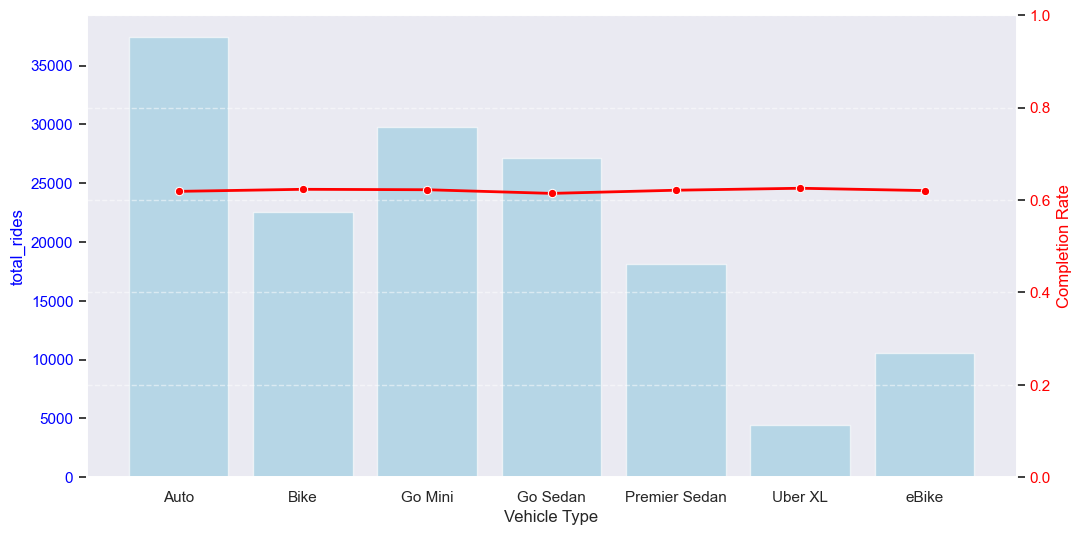

In [194]:
# 1. Aggregate data by Hour
vehicle_type_stats = df.groupby('Vehicle Type').agg(
    total_rides=('Booking ID', 'count'),
    completion_rate=('target', 'mean') # 'target' is 1 for Completed, 0 for others
).reset_index()

vehicle_type_stats['completed_rides'] = (vehicle_type_stats['total_rides']*vehicle_type_stats['completion_rate']).astype(int)

# 2. Plotting (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Volume (Demand)
sns.barplot(data=vehicle_type_stats, x='Vehicle Type', y='total_rides', color='skyblue', alpha=0.6, ax=ax1)
ax1.set_ylabel('total_rides', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line chart for Completion Rate (Reliability)
ax2 = ax1.twinx()
sns.lineplot(data=vehicle_type_stats, x='Vehicle Type', y='completion_rate', color='red', marker='o', linewidth=2, ax=ax2)
ax2.set_ylabel('Completion Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1) # Fix range 0-100%

# plt.title('The "Rush Hour" Effect: Demand vs. Reliability')
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


In [195]:
vehicle_type_stats.sort_values('completed_rides',ascending=False)

,Vehicle Type,total_rides,completion_rate,completed_rides
0,Auto,37419,0.61880,23155
2,Go Mini,29806,0.62232,18549
3,Go Sedan,27141,0.61442,16676
1,Bike,22517,0.62326,14034
4,Premier Sedan,18111,0.62128,11252
6,eBike,10557,0.62054,6551
5,Uber XL,4449,0.62553,2783


- High Demand and high completed rides vehicle categories are Auto, Go Mini, Go Sedan.
- The completion rate is consistent across different vehicle types (fluctuates very slightly)
- So the platform should not dynamically adjust supply allocation or pricing to favor the highest completion vehicle types. As we can see high completion rate vehicle type is Uber XL but the demand/volume for it is very low, and when see the Auto, Go mini, Go Sedan the demand is very high and also having good amount of completed rides. So adjusting only based on highest completion rate would be a wrong idea, and there will be no much improvement in the business outcome.
- As we have already seen that Avg CTAT (customer wait time) is the real killer for ride failure. So the buisness main focus should be to reduce customer wait time instead of focusing on vehicle category based strategies and when a customer selects book any vehicle option the platform should dynamically allocation the driver whose Avg CTAT is low(high speed of pickup) for higher probability of ride completion. But for high demand vehicle types we need to make sure that there is enough supply to avoid **No Driver Found** booking status and for high completion vehicle types we need to ensure that the customers are having high service quality by allocating these vehicles to high quality/rating drivers to avoid customer cancellations and increase demand for these high completion rate vehicle types, also the est_value_per_min should be good enough to avoid driver cancellations.

#### 7. Evaluate the model's prediction fairness by comparing its F1 -score across different major pickup zones (e.g., North vs. South NCR). If performance disparities are found, what mitigation strategy (e.g., collecting more data from minority zones, using balanced loss) must be implemented to prevent service inequality?

In [196]:
y_pred = best_model.predict(X_test)

fairness_df = pd.DataFrame()
fairness_df['Pickup Location'] = df.loc[X_test.index,'Pickup Location'].reset_index(drop=True)
fairness_df['Predicted'] = y_pred.tolist()
fairness_df['Actual'] = y_test.tolist()

# 3. Define a custom function to calculate metrics per group
def get_metrics(x):
    return pd.Series({
        'F1_Score': f1_score(x['Actual'], x['Predicted'], zero_division=0),
        'Recall': recall_score(x['Actual'], x['Predicted'], zero_division=0),
        'Precision': precision_score(x['Actual'], x['Predicted'], zero_division=0),
        'Support': len(x)
    })

# 4. Group by Location and Apply
location_metrics = fairness_df.groupby('Pickup Location').apply(get_metrics)

# 5. Filter for Statistical Significance (e.g., > 50 rides)
# We don't want to judge the model based on a location with 3 rides.
significant_locations = location_metrics[location_metrics['Support'] > 50].sort_values('F1_Score')

# 6. Display the Disparity
print("--- Fairness Audit: Worst vs. Best Served Zones ---")
print("Top 5 Worst Performing Zones (Lowest F1):")
print(significant_locations.head(5))

print("\nTop 5 Best Performing Zones (Highest F1):")
print(significant_locations.tail(5))

--- Fairness Audit: Worst vs. Best Served Zones ---
Top 5 Worst Performing Zones (Lowest F1):
                 F1_Score  Recall  Precision   Support
Pickup Location                                       
Narsinghpur       0.91919 0.98913    0.85849 167.00000
Indraprastha      0.92233 0.98958    0.86364 168.00000
Mayur Vihar       0.92486 0.98765    0.86957 144.00000
Hauz Khas         0.93000 0.97895    0.88571 163.00000
Rajiv Chowk       0.93023 0.99010    0.87719 163.00000

Top 5 Best Performing Zones (Highest F1):
                 F1_Score  Recall  Precision   Support
Pickup Location                                       
Rithala           0.98701 0.98276    0.99130 176.00000
DLF City Court    0.98723 1.00000    0.97479 181.00000
Subhash Chowk     0.98795 1.00000    0.97619 195.00000
Anand Vihar       0.99010 1.00000    0.98039 163.00000
Panchsheel Park   0.99115 1.00000    0.98246 169.00000


- The model shows a minor but distinct performance disparity (~7% gap) between top-performing and bottom-performing zones.
- Best Zones (Core/Premium): Locations like Panchsheel Park and DLF City Court achieve near-perfect reliability (F1 ~0.99).
- Worst Zones (Peripheral/Complex): Zones like Narsinghpur, Indraprastha, and Bahadurgarh lag behind (F1 ~0.92).
- The drop is driven mainly by lower precision in worst zones (~0.86).In zones like Narsinghpur, the model is "Over-Optimistic." It frequently predicts a ride will complete, but it ends up cancelling (False Positives). This creates "False Hope" for the dispatch system in these areas.
- Since FP has higher Business cost, we need to focus on imporving the precision in the worst region. To reduce the false positives in these zones we can do threshold optimization seperately for these bottom zones as these zones may have different thresholds than top performing locations. Or else we can retrain the model using sample_weight and assign 2x more weight to these bottom performing locations, this enforces the algorithm to prioritize the complex failure patterns of Narsinghpur over the easy patterns of Panchseel Park, DLF, Subhash Chowk. Another strategy is to collect detailed information regarding the ride failure from the driver in these minority zones, and feed this data back to the model so that it understands the failure pattern better in these regions.